<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 8 : Support Vector Machine

0. Why SVM?

1. Linear Separability
2. Hyperplane
3. Margin
4. Support Vectors
5. Maximum Margin Classifier
6. Soft Margin
7. Hinge Loss
8. Kernel Trick
9. Linear Kernel
10. Polynomial Kernel
11. RBF Kernel
12. Hyperparameters
13. Detailed Python Implementation (Breast Cancer Dataset)
14. Comparison with Logistic Regression
15. Questions

## 0. SVM

### 0.1 Why we need

Many classification algorithms, like Logistic Regression, are effective for linearly separable data. However, they may struggle to find an *optimal* decision boundary or perform poorly when the data is not easily separated by a simple line or plane. For instance, if data points are very close to the decision boundary, small changes in the data can lead to significant shifts in the boundary, affecting model robustness and generalization.

SVM is a powerful alternative because it aims to find the 'best' possible decision boundary, especially useful in cases where:

*   **Clear Separation Exists**: When classes are distinctly separable, SVM excels at finding a boundary that is maximally distant from the closest data points of each class, leading to better generalization.
*   **High-Dimensional Data**: SVM can effectively handle datasets with many features, even more features than observations.
*   **Non-linear Data**: Through a technique called the 'Kernel Trick', SVM can implicitly map data into a higher-dimensional space where it becomes linearly separable, thus handling complex non-linear relationships.

### 0.2 Definition

**Support Vector Machine (SVM)** is a supervised machine learning algorithm primarily used for classification tasks but can also be applied to regression. Its main goal is to find an optimal hyperplane in an N-dimensional space (N is the number of features) that distinctly classifies the data points. The 'optimal' hyperplane is defined as the one that has the largest margin between the closest training data points of any class, thus providing better accuracy and generalization.

### 0.3 Intuition

Imagine you have two different types of objects (e.g., apples and oranges) scattered on a table, and you want to draw a line that separates them. There might be many lines you could draw. SVM's intuition is to find the line that not only separates the apples from the oranges but also keeps the line as far away as possible from the apples closest to the line and the oranges closest to the line. These closest points are called 'Support Vectors'. By maximizing this 'margin' (the distance between the line and the support vectors), the SVM creates a robust classifier that is less sensitive to individual data points and generalizes better to new, unseen data.

### 0.4 Math behind

the mathematical details are embedded in the concepts of the hyperplane, margin, and optimization, which will be covered in subsequent sections. The 'why' is more about the practical advantages and limitations of other models that SVM seeks to overcome, rather than specific mathematical derivation at this introductory stage.

### 0.5 Comparison with previous or similar algo

**Comparison with Logistic Regression:**

While both SVM and Logistic Regression are linear classifiers, their fundamental approach to finding a decision boundary differs:

*   **Logistic Regression** aims to maximize the likelihood of the training data, essentially finding a boundary that best separates the classes by modeling the probability of belonging to a class. It focuses on classifying all data points correctly.
*   **SVM**, on the other hand, focuses on finding the widest possible margin between the classes, prioritizing the most difficult-to-classify points (support vectors). It's a 'large margin classifier' that aims for robustness and better generalization, especially in high-dimensional spaces or when non-linear separation is required via kernels.

## 1. Linear Separability

### 1.1 Why we need

Understanding **linear separability** is fundamental to grasping the simplest form of Support Vector Machines. It represents the ideal scenario where a straightforward linear boundary can perfectly distinguish between different classes. For such cases, a basic SVM (specifically, a hard-margin SVM) can perform optimally. This concept sets the stage for understanding how SVM extends its capabilities to more complex, non-linear data through the 'kernel trick', as it first identifies what constitutes a 'simple' separation.

### 1.2 Definition

**Linear Separability** refers to a property of a dataset where two or more classes can be completely separated by a single straight line (in 2D), a plane (in 3D), or more generally, a hyperplane (in higher dimensions). This means that there exists a linear decision boundary such that all data points of one class fall entirely on one side of the boundary, and all data points of the other class fall entirely on the opposite side, with no overlap or points residing on the boundary itself.

### 1.3 Intuition

Imagine you have a collection of blue and red marbles scattered on a table. If you can draw a single, perfectly straight line on the table such that all the blue marbles are on one side of the line and all the red marbles are on the other side, then the marbles are **linearly separable**. If no matter how you draw a straight line, some blue marbles always end up on the red side or vice versa, then they are not linearly separable. It's like building a fence that perfectly divides two different groups without any member of one group crossing into the other's territory.

### 1.4 Math behind

Mathematically, two classes are linearly separable if there exists a vector $\mathbf{w}$ (the normal vector to the hyperplane) and a scalar $b$ (the bias term) such that for every data point $\mathbf{x}_i$ with its corresponding class label $y_i \in \{-1, 1\}$:

$$ y_i (\mathbf{w} \cdot \mathbf{x}_i + b) > 0 $$

This inequality means that all points of class $1$ will result in a positive value for $(\mathbf{w} \cdot \mathbf{x}_i + b)$, and all points of class $-1$ will result in a negative value. The hyperplane itself is defined by the equation $\mathbf{w} \cdot \mathbf{x} + b = 0$. The strict inequality `>` ensures that no points lie *on* the separating boundary, which is the definition for strict linear separability (hard margin).

### 1.5 Formula

The fundamental formula describing a linearly separating hyperplane in an N-dimensional space is:

$$ \mathbf{w} \cdot \mathbf{x} + b = 0 $$

Where:
*   $\mathbf{w} = [w_1, w_2, \ldots, w_N]$ is the weight vector (normal to the hyperplane).
*   $\mathbf{x} = [x_1, x_2, \ldots, x_N]$ is a vector representing a point in the N-dimensional space.
*   $b$ is the bias term (also known as the intercept).

For a 2D space, this simplifies to $w_1 x_1 + w_2 x_2 + b = 0$, which is the equation of a line. For a 3D space, it's $w_1 x_1 + w_2 x_2 + w_3 x_3 + b = 0$, the equation of a plane.

### 1.6 Numerical Example

Consider the following two classes of 2D data points:

**Class A (label $y=1$):**
*   $P_1 = (1, 2)$
*   $P_2 = (2, 3)$

**Class B (label $y=-1$):**
*   $P_3 = (-1, 0)$
*   $P_4 = (0, 1)$

We can see that these points are linearly separable. A possible separating line could be $x_1 - x_2 + 1.5 = 0$. Let's test it:

*   For $P_1(1, 2)$, $y=1$: $(1) - (2) + 1.5 = 0.5 > 0$. $y_1(0.5) = 1(0.5) > 0$. Correct.
*   For $P_2(2, 3)$, $y=1$: $(2) - (3) + 1.5 = 0.5 > 0$. $y_1(0.5) = 1(0.5) > 0$. Correct.
*   For $P_3(-1, 0)$, $y=-1$: $(-1) - (0) + 1.5 = 0.5$. $y_3(0.5) = -1(0.5) = -0.5 < 0$. Correct.
*   For $P_4(0, 1)$, $y=-1$: $(0) - (1) + 1.5 = 0.5$. $y_4(0.5) = -1(0.5) = -0.5 < 0$. Correct.

Since all points satisfy the condition $y_i (\mathbf{w} \cdot \mathbf{x}_i + b) > 0$ for this chosen hyperplane (with $\mathbf{w}=[1, -1]$ and $b=1.5$), the data is indeed linearly separable.

### 1.7 Python code implementation (take small data for easy understanding) with graphs

First, let's create the data points in Python and visualize them to confirm linear separability.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data points for Class A (y=1)
X_A = np.array([[1, 2], [2, 3]])
y_A = np.array([1, 1])

# Data points for Class B (y=-1)
X_B = np.array([[-1, 0], [0, 1]])
y_B = np.array([-1, -1])

# Combine data
X = np.vstack((X_A, X_B))
y = np.hstack((y_A, y_B))

print("Features (X):")
print(X)
print("Labels (y):")
print(y)

Features (X):
[[ 1  2]
 [ 2  3]
 [-1  0]
 [ 0  1]]
Labels (y):
[ 1  1 -1 -1]


### 1.8 Visualisation

Let's visualize these data points and draw the separating hyperplane we found ($x_1 - x_2 + 1.5 = 0$ or $x_2 = x_1 + 1.5$) to illustrate linear separability.


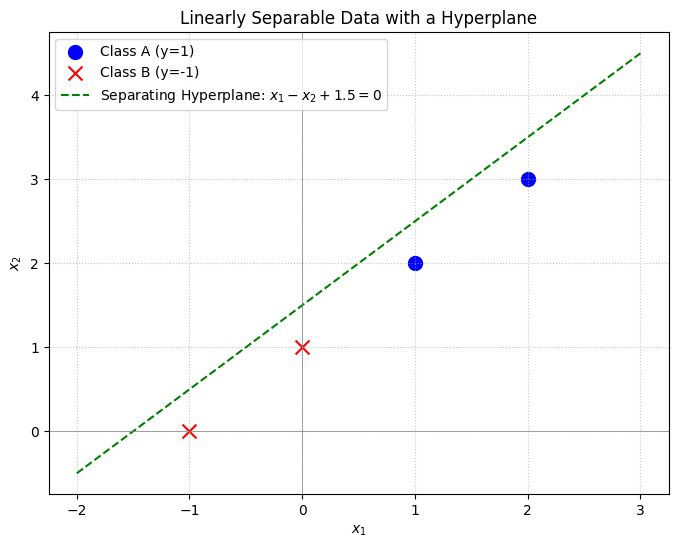

In [2]:
plt.figure(figsize=(8, 6))
plt.scatter(X_A[:, 0], X_A[:, 1], color='blue', label='Class A (y=1)', marker='o', s=100)
plt.scatter(X_B[:, 0], X_B[:, 1], color='red', label='Class B (y=-1)', marker='x', s=100)

# Plot the separating hyperplane: x_2 = x_1 + 1.5
x_vals = np.linspace(-2, 3, 100)
y_vals = x_vals + 1.5
plt.plot(x_vals, y_vals, color='green', linestyle='--', label='Separating Hyperplane: $x_1 - x_2 + 1.5 = 0$')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Linearly Separable Data with a Hyperplane')
plt.axvline(0, color='gray', linewidth=0.5)
plt.axhline(0, color='gray', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 1.9 Comparison with previous or similar algo

**Linear Discriminant Analysis (LDA) and Perceptron Algorithm:**

*   **Perceptron Algorithm**: The Perceptron is another classic linear classifier. If data is linearly separable, the Perceptron algorithm is guaranteed to find *a* separating hyperplane. However, it doesn't necessarily find the *optimal* one (i.e., one with the largest margin). The Perceptron focuses on correcting misclassifications until all points are correctly classified.
*   **Linear Discriminant Analysis (LDA)**: LDA also seeks a linear boundary. It works by finding a linear combination of features that best separates two or more classes. It maximizes the ratio of between-class variance to within-class variance. While it can define a linear separator, it does not explicitly focus on maximizing the margin between classes in the same way SVM does.

Both the Perceptron and LDA aim for linear separation, but SVM, particularly the Hard Margin SVM (for linearly separable data), uniquely focuses on finding the **maximum margin** hyperplane, which often leads to better generalization and robustness.

## 2. Hyperplane

### 2.1 Why we need

The **hyperplane** is the central concept in Support Vector Machines, serving as the fundamental decision boundary that separates different classes of data points. Understanding the nature and properties of the hyperplane is crucial because it's what the SVM algorithm is ultimately trying to find and optimize. The entire goal of SVM is to determine the 'best' hyperplane that maximizes the margin between classes, thereby defining the classification rule. Without a hyperplane, there is no way to define the separation between classes in a geometric sense, making it indispensable for classification.

### 2.2 Definition

In an N-dimensional feature space, a **hyperplane** is a subspace of N-1 dimensions. It effectively divides the N-dimensional space into two half-spaces. For example:

*   In a 2-dimensional space (data with two features, like our `x1` and `x2`), a hyperplane is a **line**.
*   In a 3-dimensional space (data with three features), a hyperplane is a **plane**.
*   In spaces with more than three dimensions, it's simply referred to as a hyperplane, though it becomes impossible to visualize directly. We still refer to it conceptually.

In the context of SVM, the hyperplane is the decision boundary that separates the input space into two regions, with each region corresponding to a different class label.

### 2.3 Intuition

Think of the hyperplane as the ultimate 'dividing surface' or 'decision boundary' that the SVM algorithm creates. If you're classifying emails into 'spam' or 'not spam' based on thousands of word frequencies (making it a high-dimensional problem), the hyperplane is the mathematical rule that decides whether an email falls into the 'spam' region or the 'not spam' region. It's the invisible wall that separates the different categories in your data, helping the model make a prediction. The SVM's magic lies in finding the 'best' possible placement and orientation for this wall, ensuring the most robust separation possible.

### 2.4 Math behind

Mathematically, a hyperplane is defined by a linear equation. For a given data point $\mathbf{x}$ (a vector of features), the hyperplane equation is:

$$ \mathbf{w} \cdot \mathbf{x} + b = 0 $$

Where:
*   $\mathbf{w}$ (the weight vector) is a vector perpendicular (normal) to the hyperplane. Its direction indicates the orientation of the decision boundary, and its magnitude is related to the margin.
*   $\mathbf{x}$ is a vector representing a point in the feature space.
*   $b$ (the bias or intercept term) determines the offset of the hyperplane from the origin. It shifts the hyperplane up or down (or left/right, etc.).

Any point $\mathbf{x}$ that satisfies this equation lies *on* the hyperplane. If $\mathbf{w} \cdot \mathbf{x} + b > 0$, the point lies on one side of the hyperplane. If $\mathbf{w} \cdot \mathbf{x} + b < 0$, it lies on the other side.

### 2.5 Formula

The general formula for a hyperplane in an N-dimensional space is:

$$ w_1 x_1 + w_2 x_2 + \ldots + w_N x_N + b = 0 $$

Or in vector notation:

$$ \mathbf{w}^T \mathbf{x} + b = 0 $$

This formula explicitly shows how the features $x_i$ are linearly combined with their respective weights $w_i$ and an intercept $b$ to define the boundary.

### 2.6 Numerical Example

Let's reuse our previous 2D example for linear separability:

**Class A (label $y=1$):** $(1, 2), (2, 3)$
**Class B (label $y=-1$):** $(-1, 0), (0, 1)$

We previously identified a separating hyperplane as $x_1 - x_2 + 1.5 = 0$.

Here, the parameters of the hyperplane are:
*   $\mathbf{w} = [1, -1]$ (meaning $w_1 = 1$, $w_2 = -1$)
*   $b = 1.5$

Let's pick a point, for instance, $(0, 2)$, and see where it lies relative to this hyperplane:

$$(1)(0) + (-1)(2) + 1.5 = 0 - 2 + 1.5 = -0.5$$

Since $-0.5 < 0$, this point $(0, 2)$ would be classified on the side corresponding to Class B (label -1). Indeed, looking at the previous plot, $(0,2)$ is below the line, on the side of the red 'x' marks.

### 2.7 Python code implementation (take small data for easy understanding) with graphs

We have already set up the data and plotted a hyperplane in the previous section. Here, we can specifically extract and highlight the hyperplane parameters.


Weight vector (w): [ 1 -1]
Bias term (b): 1.5


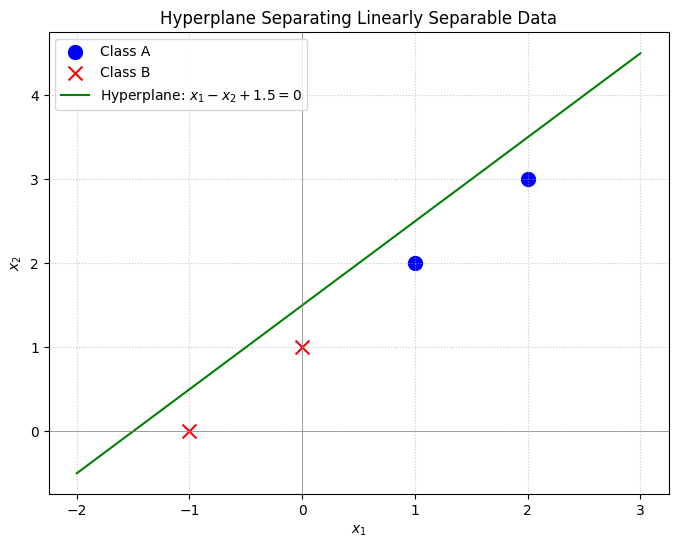

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data points from previous example
X_A = np.array([[1, 2], [2, 3]])
X_B = np.array([[-1, 0], [0, 1]])

# Hyperplane parameters (from x1 - x2 + 1.5 = 0)
w = np.array([1, -1])  # [w1, w2]
b = 1.5

print(f"Weight vector (w): {w}")
print(f"Bias term (b): {b}")

plt.figure(figsize=(8, 6))
plt.scatter(X_A[:, 0], X_A[:, 1], color='blue', label='Class A', marker='o', s=100)
plt.scatter(X_B[:, 0], X_B[:, 1], color='red', label='Class B', marker='x', s=100)

# Plot the hyperplane: x2 = (w1*x1 + b) / -w2
x_vals = np.linspace(-2, 3, 100)
y_vals_hyperplane = (-w[0] * x_vals - b) / w[1]
plt.plot(x_vals, y_vals_hyperplane, color='green', linestyle='-', label='Hyperplane: $x_1 - x_2 + 1.5 = 0$')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Hyperplane Separating Linearly Separable Data')
plt.axvline(0, color='gray', linewidth=0.5)
plt.axhline(0, color='gray', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 2.8 Visualisation

The plot above clearly shows the data points and the hyperplane (green line) that separates them. The hyperplane acts as the decision boundary. Any new data point falling above this line would be classified into Class A (blue circles), and any point falling below it would be classified into Class B (red crosses).

### 2.9 Comparison with previous or similar algo

**Perceptron vs. SVM Hyperplane:**

*   **Perceptron Algorithm**: The Perceptron also finds a hyperplane to separate data. However, if multiple separating hyperplanes exist, the Perceptron algorithm might converge to any one of them. It doesn't have a mechanism to choose the 'best' one based on any optimality criterion other than correctly classifying all training points.
*   **Support Vector Machine (SVM)**: While both find a hyperplane, SVM explicitly seeks the *optimal* hyperplane – one that maximizes the margin between the two classes. This focus on maximizing the margin makes the SVM's hyperplane more robust and leads to better generalization performance on unseen data compared to a hyperplane found by the Perceptron.

## 3. Margin

### 3.1 Why we need

When we find a hyperplane that separates two classes, there are often many such hyperplanes, especially if the data is easily separable. The concept of **margin** helps us identify the *optimal* hyperplane among these many possibilities. A hyperplane with a larger margin is generally preferred because it provides a more robust and generalized separation. This robustness is crucial as it allows the classifier to handle new, unseen data more effectively, being less prone to misclassifications due to minor variations or noise in the data. Without the margin concept, the SVM wouldn't have a clear, mathematically sound criterion to select the 'best' decision boundary, leading to potentially unstable classifiers.

### 3.2 Definition

The **margin** in an SVM is defined as the distance between the separating hyperplane and the closest data points from either class. These closest data points are known as **Support Vectors**. The SVM algorithm seeks to find the hyperplane that maximizes this margin. There are two primary types of margins:

*   **Hard Margin**: This applies when the data is perfectly linearly separable, and no data points are allowed to fall within the margin or on the wrong side of the hyperplane. It enforces a strict separation.
*   **Soft Margin**: This is an extension used when the data is not perfectly linearly separable or contains outliers. It allows for some misclassifications or points to be within the margin, balancing the desire for a large margin with the need to correctly classify most training examples. This will be discussed in a later section.

### 3.3 Intuition

Imagine you're trying to separate two groups of people (e.g., basketball players and gymnasts) with a rope. You could place the rope anywhere between them. The 'margin' is like the empty space on either side of the rope, between the rope and the person closest to it from each group. SVM's goal is to place the rope in such a way that this empty space, or 'margin', is as wide as possible. The wider the margin, the more confident you are that the rope effectively separates the two groups, and the less likely it is that a new person (who wasn't part of the original groups) would accidentally fall on the wrong side of the rope. This maximal 'buffer zone' increases the classifier's reliability.

### 3.4 Math behind

Consider a hyperplane defined by $\mathbf{w} \cdot \mathbf{x} + b = 0$. The data points closest to the hyperplane (the support vectors) define two parallel hyperplanes, one for each class:

*   $H_1: \mathbf{w} \cdot \mathbf{x} + b = 1$ (for class $y=1$)
*   $H_{-1}: \mathbf{w} \cdot \mathbf{x} + b = -1$ (for class $y=-1$)

For all points $\mathbf{x}_i$ in the dataset, the condition $y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1$ must hold. The distance between $H_1$ and $H_{-1}$ is the margin. The distance between two parallel hyperplanes $\mathbf{w} \cdot \mathbf{x} + b_1 = 0$ and $\mathbf{w} \cdot \mathbf{x} + b_2 = 0$ is given by $\frac{|b_1 - b_2|}{\|\mathbf{w}\|}$.

In our case, for $H_1$, the equivalent $b$ is $-1$, and for $H_{-1}$, the equivalent $b$ is $1$ (if we rewrite them as $\mathbf{w} \cdot \mathbf{x} + (b-1) = 0$ and $\mathbf{w} \cdot \mathbf{x} + (b+1) = 0$ ). More simply, the distance from the origin to $\mathbf{w} \cdot \mathbf{x} + b = C$ is $\frac{|C-b|}{\|\mathbf{w}\|}$. So, the distance from the origin to $H_1$ is $\frac{|1-b|}{\|\mathbf{w}\|}$ and to $H_{-1}$ is $\frac{|-1-b|}{\|\mathbf{w}\|}$.

The total margin is the sum of the distances from the separating hyperplane to these two parallel hyperplanes. The distance from the hyperplane $\mathbf{w} \cdot \mathbf{x} + b = 0$ to a point $\mathbf{x}_0$ is $\frac{|\mathbf{w} \cdot \mathbf{x}_0 + b|}{\|\mathbf{w}\|}$. For a support vector, this is $\frac{1}{\|\mathbf{w}\|}$. Since there's one such distance on each side, the total margin is $\frac{2}{\|\mathbf{w}\|}$.

### 3.5 Formula

The margin, $\gamma$, of the Support Vector Machine is given by:

$$ \gamma = \frac{2}{\|\mathbf{w}\|} $$

The objective of the Maximum Margin Classifier is to maximize this margin, which is equivalent to minimizing $\|\mathbf{w}\|$ (or $\frac{1}{2}\|\mathbf{w}\|^2$ for computational reasons), subject to the constraint that all data points are correctly classified with a functional margin of at least 1:

**Maximize:** $\frac{2}{\|\mathbf{w}\|}$

**Equivalent to Minimizing:** $\frac{1}{2}\|\mathbf{w}\|^2$

**Subject to:** $y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1 \quad \text{for all } i = 1, \ldots, N$

### 3.6 Numerical Example

Let's consider a simplified 1D example for clarity, where points are along a number line.

*   Class 1 ($y=1$): points at $x=1$ and $x=2$
*   Class 2 ($y=-1$): points at $x=-1$ and $x=-2$

Here, the feature space is 1-dimensional, so the hyperplane is a single point. If we choose the separating point (hyperplane) at $x=0$, then $\mathbf{w}$ is just a scalar $w$, and $b$ is also a scalar.

Let's assume the optimal solution gives $w=1$ and $b=0$. The hyperplane is $1 \cdot x + 0 = 0 \implies x=0$.

Then the support vector equations become:
*   $1 \cdot x + 0 = 1 \implies x=1$ (for $y=1$ class)
*   $1 \cdot x + 0 = -1 \implies x=-1$ (for $y=-1$ class)

The closest points to the hyperplane $x=0$ are $x=1$ (from class 1) and $x=-1$ (from class 2). These are our support vectors.

Now, let's calculate the margin:
*   $\mathbf{w} = [1]$ (as a vector in 1D), so $\|\mathbf{w}\| = \sqrt{1^2} = 1$.
*   Margin $= \frac{2}{\|\mathbf{w}\|} = \frac{2}{1} = 2$.

Visually, the distance from $x=0$ to $x=1$ is 1, and from $x=0$ to $x=-1$ is 1. The total distance between the support vectors is $1 - (-1) = 2$, which matches our formula.

### 3.7 Python code implementation (take small data for easy understanding) with graphs

We will use `sklearn.svm.SVC` to demonstrate a simple hard-margin SVM and visualize the margin. Note that `SVC` by default implements a soft-margin SVM, but for perfectly separable data, it will behave like a hard-margin one if `C` (regularization parameter) is set sufficiently high.


Weight vector (w): [1. 1.]
Bias term (b): -2.0
Calculated margin (2/||w||): 1.414213562373095


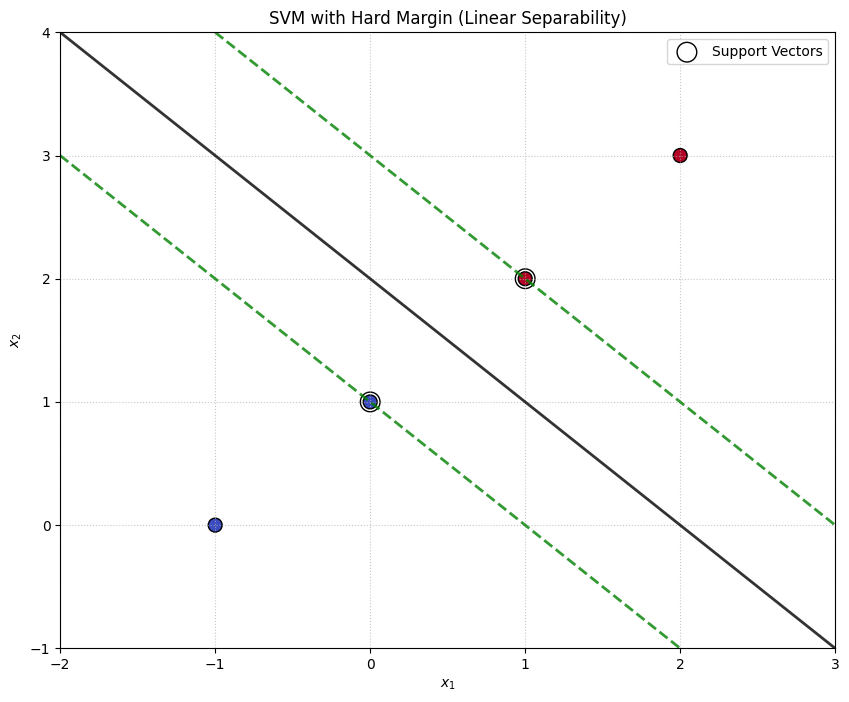

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# Data points from previous example (linearly separable)
X = np.array([[1, 2], [2, 3], [-1, 0], [0, 1]])
y = np.array([1, 1, -1, -1])

# Create an SVM classifier with a linear kernel and a high C (approximates hard margin)
clf = svm.SVC(kernel='linear', C=10000) # High C encourages hard margin
clf.fit(X, y)

# Get the separating hyperplane equation: w1*x1 + w2*x2 + b = 0
w = clf.coef_[0]
b = clf.intercept_[0]

# Output the coefficients and intercept
print(f"Weight vector (w): {w}")
print(f"Bias term (b): {b}")
print(f"Calculated margin (2/||w||): {2 / np.linalg.norm(w)}")

# Create a mesh to plot decision boundary and margins
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Calculate decision function for each point in the mesh
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the data points
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=100, edgecolors='k')

# Plot the decision boundary (hyperplane) and margins
plt.contour(xx, yy, Z, colors=['g', 'k', 'g'], levels=[-1, 0, 1], alpha=0.8,
            linestyles=['--', '-', '--'], linewidths=[2, 2, 2])

# Plot the support vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=200, facecolors='none', edgecolors='k', marker='o', label='Support Vectors')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('SVM with Hard Margin (Linear Separability)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 3.8 Visualisation

The plot above clearly illustrates the concept of the margin. The solid black line is the optimal separating hyperplane. The dashed green lines on either side of the hyperplane represent the boundaries of the margin. The data points circled in black are the **support vectors**; these are the points that lie directly on the margin boundaries. Notice how these support vectors are the closest points from each class to the hyperplane, and they are the only points that dictate the position of the hyperplane and the width of the margin.

### 3.9 Comparison with previous or similar algo

**Margin in SVM vs. Other Linear Classifiers (Logistic Regression, Perceptron):**

*   **Logistic Regression**: While Logistic Regression also finds a linear decision boundary, it does not explicitly define or optimize a 'margin' in the geometric sense. Its goal is to model probabilities and classify points based on a threshold (typically 0.5 probability), focusing on minimizing misclassification errors across all training data points. The resulting decision boundary may not be the one that provides the largest separation.
*   **Perceptron Algorithm**: The Perceptron finds *any* hyperplane that correctly separates the data (if linearly separable). It does not have a mechanism to maximize the distance between the classes or define a margin. It simply seeks a boundary where all points are on the correct side. If multiple such boundaries exist, the Perceptron's chosen boundary is dependent on initialization and order of training examples.
*   **Support Vector Machine (SVM)**: SVM's unique strength lies in its explicit objective to maximize the geometric margin. This fundamental difference makes SVM's decision boundary generally more robust and leads to better generalization performance, especially when the classes are well-separated.

## 4. Support Vectors

### 4.1 Why we need

**Support Vectors** are critical because they are the *only* data points that directly influence the position and orientation of the separating hyperplane and, consequently, the margin. Without identifying these crucial points, it would be difficult to define the optimal boundary that maximizes the margin. They distill the essence of the dataset's separability problem, allowing the SVM algorithm to efficiently find the best classifier by focusing only on these boundary-defining samples rather than all training data. This is particularly beneficial for large datasets, as it significantly reduces computational complexity; only a subset of the training data (the support vectors) is needed for prediction. This concept also explains why SVMs can be less prone to overfitting than some other algorithms.

### 4.2 Definition

**Support Vectors** are the data points from the training set that lie closest to the separating hyperplane. These are the points that define the 'margin' of the classifier. If these points were removed or moved, the position of the hyperplane would change. All other data points, which lie further away from the hyperplane (outside the margin), do not influence the definition of the decision boundary. Therefore, support vectors are the most critical elements of the training dataset for the SVM model; they are the 'support' for the separating hyperplane.

### 4.3 Intuition

Imagine you are building a fence to separate two yards. You only need to consider the trees or obstacles that are *closest* to where you want to put the fence. Any trees far away from the fence line don't affect its placement. In SVM, the 'Support Vectors' are like those closest trees or obstacles. They are the few, crucial data points that, if moved, would force you to move your separating fence (the hyperplane). All the other data points, far away from the boundary, don't matter as much for defining where the fence goes. SVM focuses its attention solely on these 'support vectors' to draw the best possible separation line, making it efficient and robust.

### 4.4 Math behind

Mathematically, for a given hyperplane $\mathbf{w} \cdot \mathbf{x} + b = 0$, support vectors are the points $\mathbf{x}_i$ for which the functional margin is exactly 1 (or -1).

That is, for support vectors, the following condition holds:

$$ y_i (\mathbf{w} \cdot \mathbf{x}_i + b) = 1 $$

These points lie directly on the parallel hyperplanes $H_1: \mathbf{w} \cdot \mathbf{x} + b = 1$ and $H_{-1}: \mathbf{w} \cdot \mathbf{x} + b = -1$. The distance of these points from the separating hyperplane $\mathbf{w} \cdot \mathbf{x} + b = 0$ is exactly $\frac{1}{\|\mathbf{w}\|}$. This mathematical condition defines their unique role in determining the hyperplane and the margin.

### 4.5 Formula

There isn't a separate formula *for* support vectors themselves, but rather a condition that defines them within the SVM optimization problem. The core formula that identifies them is:

$$ y_i (\mathbf{w} \cdot \mathbf{x}_i + b) = 1 $$

This condition is a key part of the Karush-Kuhn-Tucker (KKT) conditions in the optimization process for SVMs, indicating that the Lagrange multipliers corresponding to these support vectors will be non-zero.

### 4.6 Numerical Example

Let's reconsider our previous 2D example from the 'Margin' section where we used `sklearn.svm.SVC`. The SVM algorithm determined the optimal hyperplane and, as a byproduct, identified the support vectors. In that example, our data points were:

*   Class 1 ($y=1$): $P_1 = (1, 2)$, $P_2 = (2, 3)$
*   Class 2 ($y=-1$): $P_3 = (-1, 0)$, $P_4 = (0, 1)$

And the SVM (with `C=10000`) found $\mathbf{w} = [1, 1]$ and $b = -2.0$. The separating hyperplane is $x_1 + x_2 - 2 = 0$.

Let's check each point's functional margin:

*   For $P_1(1, 2)$, $y=1$: $y_1 (1 \cdot 1 + 1 \cdot 2 - 2) = 1 (1 + 2 - 2) = 1(1) = 1$. **$P_1$ is a Support Vector.**
*   For $P_2(2, 3)$, $y=1$: $y_2 (1 \cdot 2 + 1 \cdot 3 - 2) = 1 (2 + 3 - 2) = 1(3) = 3$. This point is *not* a Support Vector as $3 > 1$.
*   For $P_3(-1, 0)$, $y=-1$: $y_3 (1 \cdot (-1) + 1 \cdot 0 - 2) = -1 (-1 + 0 - 2) = -1 (-3) = 3$. This point is *not* a Support Vector as $3 > 1$.
*   For $P_4(0, 1)$, $y=-1$: $y_4 (1 \cdot 0 + 1 \cdot 1 - 2) = -1 (0 + 1 - 2) = -1 (-1) = 1$. **$P_4$ is a Support Vector.**

So, in this example, the support vectors are $(1, 2)$ and $(0, 1)$. These are the points that lie exactly on the margin boundaries, defining the optimal separating hyperplane.

### 4.7 Python code implementation (take small data for easy understanding) with graphs

We will use the same Python code as in the 'Margin' section, as `sklearn.svm.SVC` directly provides access to the support vectors through the `support_vectors_` attribute. We will highlight them more explicitly.

Support Vectors:
 [[0. 1.]
 [1. 2.]]


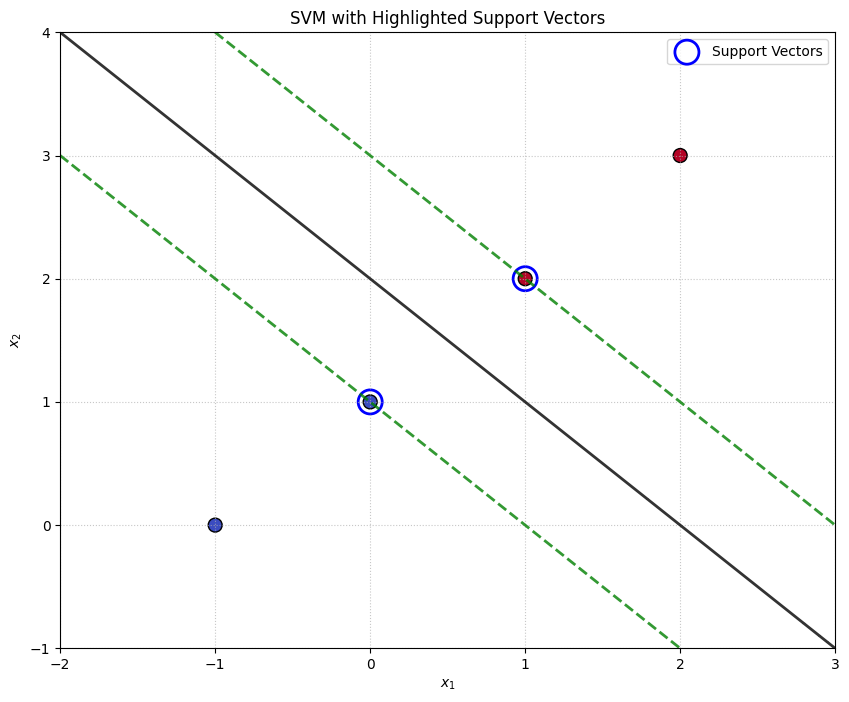

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# Data points from previous example (linearly separable)
X = np.array([[1, 2], [2, 3], [-1, 0], [0, 1]])
y = np.array([1, 1, -1, -1])

# Create an SVM classifier with a linear kernel and a high C (approximates hard margin)
# C=10000 ensures a hard margin if data is separable
clf = svm.SVC(kernel='linear', C=10000)
clf.fit(X, y)

# Get the support vectors
support_vectors = clf.support_vectors_

print("Support Vectors:\n", support_vectors)

# Get the separating hyperplane equation: w1*x1 + w2*x2 + b = 0
w = clf.coef_[0]
b = clf.intercept_[0]

# Create a mesh to plot decision boundary and margins
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Calculate decision function for each point in the mesh
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the data points
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=100, edgecolors='k')

# Plot the decision boundary (hyperplane) and margins
plt.contour(xx, yy, Z, colors=['g', 'k', 'g'], levels=[-1, 0, 1], alpha=0.8,
            linestyles=['--', '-', '--'], linewidths=[2, 2, 2])

# Plot the support vectors with larger, distinct markers
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=300, facecolors='none', edgecolors='blue', linewidth=2, label='Support Vectors')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('SVM with Highlighted Support Vectors')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 4.8 Visualisation

The plot clearly shows the data points, the separating hyperplane (solid black line), and the margin boundaries (dashed green lines). Crucially, the **Support Vectors** are distinctly highlighted with larger blue circles. You can observe that these highlighted points are indeed the ones lying directly on the margin boundaries. They are the closest points from each class to the decision boundary, thus 'supporting' its position.

### 4.9 Comparison with previous or similar algo

**Support Vectors vs. Other Classifiers' Influential Points:**

*   **Logistic Regression / Perceptron**: These algorithms typically use *all* training data points to determine their decision boundary. There isn't a concept of a small, influential subset like support vectors. Every point contributes to the gradient descent process or error minimization.
*   **Decision Trees / Random Forests**: These algorithms make decisions based on splitting data at various thresholds. While certain data points might be critical in defining a split, there isn't a formalized concept of 'support vectors' that define the overall decision boundary in a geometric sense.
*   **Support Vector Machine (SVM)**: The reliance solely on support vectors makes SVM computationally efficient during prediction (as only distances to support vectors need to be calculated, especially with kernel tricks) and inherently robust. This 'sparsity' in representation (only support vectors matter) is a distinguishing feature of SVM compared to many other machine learning models that depend on the entire training set for model definition.

## 5. Maximum Margin Classifier

### 5.1 Why we need

In the context of linearly separable data, there can be an infinite number of hyperplanes that successfully separate the classes. If any of these separating hyperplanes are chosen arbitrarily, the resulting classifier might be sensitive to small changes in the training data, leading to poor generalization on unseen data. The **Maximum Margin Classifier** addresses this by providing a principled way to select the *best* among these many separating hyperplanes. It aims to find a hyperplane that is not only separating but also maximally robust to variations in data, thereby improving the model's ability to classify new observations correctly. This robustness comes from maximizing the 'buffer zone' (margin) between the classes.

### 5.2 Definition

The **Maximum Margin Classifier** is a linear classifier that finds the hyperplane that best separates two classes of data by maximizing the margin between them. This classifier is defined by the decision boundary that is furthest from the nearest training data points of both classes (the support vectors). It is applicable only when the data is perfectly linearly separable and no training errors are allowed, hence often referred to as a 'hard-margin' SVM. The data points that lie on the margin boundaries are called support vectors, and they are the only points that influence the position of the maximum margin hyperplane.

### 5.3 Intuition

Imagine you have two distinct groups of items, and you want to draw a dividing line. Many lines could separate them. However, if you want that dividing line to be the most 'stable' or 'safest' one – meaning it's less likely to accidentally misclassify new items that are slightly different from your training examples – you'd want to place it as far away as possible from any item in either group. The Maximum Margin Classifier does precisely this: it finds the widest possible 'empty street' between the two classes, and the center line of that street is its decision boundary. This 'street' is the margin, and by maximizing its width, the classifier gains robustness and improved generalization capabilities. It's like finding the biggest possible gap to run a railway line between two cities, ensuring no buildings are too close to the tracks.

### 5.4 Math behind

As discussed in the 'Margin' section (3.4), a hyperplane is defined by $\mathbf{w} \cdot \mathbf{x} + b = 0$. The objective of the Maximum Margin Classifier is to maximize the geometric margin, $\frac{2}{\|\mathbf{w}\|}$. This is equivalent to minimizing $\|\mathbf{w}\|$ (or $\frac{1}{2}\|\mathbf{w}\|^2$ for easier differentiation in optimization) subject to the constraint that all training points are correctly classified and lie outside the margin.

The constraint for each data point $(\mathbf{x}_i, y_i)$ is:
$$ y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1 $$

This means for $y_i = 1$, we need $\mathbf{w} \cdot \mathbf{x}_i + b \ge 1$. For $y_i = -1$, we need $\mathbf{w} \cdot \mathbf{x}_i + b \le -1$. The support vectors are the points where the equality holds, i.e., $y_i (\mathbf{w} \cdot \mathbf{x}_i + b) = 1$.

This problem is a convex quadratic programming problem, which has a unique global minimum. It can be solved efficiently using optimization techniques, often involving Lagrange multipliers to incorporate the constraints.

### 5.5 Formula

The optimization problem for the Maximum Margin Classifier is formally stated as:

**Minimize:**
$$ \frac{1}{2} \|\mathbf{w}\|^2 $$

**Subject to:**
$$ y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1 \quad \text{for all } i = 1, \ldots, N $$

Where $N$ is the number of training samples, $\mathbf{w}$ is the weight vector, $b$ is the bias term, $\mathbf{x}_i$ is the $i$-th training sample, and $y_i$ is its corresponding class label (either $1$ or $-1$).

### 5.6 Numerical Example

Let's use the same linearly separable 2D dataset from previous sections, where the SVM identified the optimal hyperplane and support vectors. The optimization problem described above is solved by the SVM algorithm to find the specific values for $\mathbf{w}$ and $b$.

Data points:
*   Class 1 ($y=1$): $(1, 2)$, $(2, 3)$
*   Class 2 ($y=-1$): $(-1, 0)$, $(0, 1)$

From the previous `sklearn` example, the trained SVM (approximating a hard margin) yielded:
*   Weight vector $\mathbf{w} = [1, 1]$
*   Bias term $b = -2.0$

So the optimal separating hyperplane is $x_1 + x_2 - 2 = 0$.

Let's verify the constraints for all points using this $\mathbf{w}$ and $b$:
*   For $P_1(1, 2)$, $y_1=1$: $1 \cdot (1 + 2 - 2) = 1 \cdot 1 = 1 \ge 1$. (Support Vector)
*   For $P_2(2, 3)$, $y_1=1$: $1 \cdot (2 + 3 - 2) = 1 \cdot 3 = 3 \ge 1$. (Not a Support Vector)
*   For $P_3(-1, 0)$, $y_1=-1$: $-1 \cdot (-1 + 0 - 2) = -1 \cdot (-3) = 3 \ge 1$. (Not a Support Vector)
*   For $P_4(0, 1)$, $y_1=-1$: $-1 \cdot (0 + 1 - 2) = -1 \cdot (-1) = 1 \ge 1$. (Support Vector)

All points satisfy the constraint, and the points $(1,2)$ and $(0,1)$ are identified as support vectors because their functional margin is exactly 1. The margin for this classifier is $\frac{2}{\|\mathbf{w}\|} = \frac{2}{\sqrt{1^2 + 1^2}} = \frac{2}{\sqrt{2}} = \sqrt{2} \approx 1.414$.

### 5.7 Python code implementation (take small data for easy understanding) with graphs

We will re-use the `sklearn.svm.SVC` to demonstrate the Maximum Margin Classifier, explicitly showing the derived $\mathbf{w}$ and $b$ values and the resulting margin. This is essentially a hard-margin SVM, which is what the Maximum Margin Classifier is.


Learned Weight vector (w): [1. 1.]
Learned Bias term (b): -2.0
Support Vectors:
[[0. 1.]
 [1. 2.]]
Calculated Margin (2/||w||): 1.414


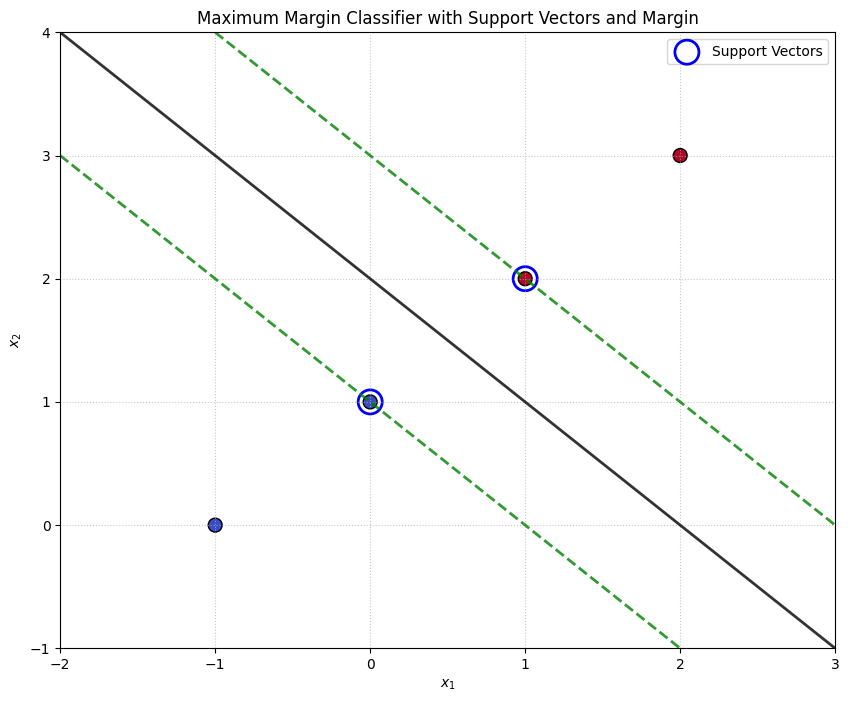

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# Data points from previous example (linearly separable)
X = np.array([[1, 2], [2, 3], [-1, 0], [0, 1]])
y = np.array([1, 1, -1, -1])

# Create an SVM classifier with a linear kernel and a high C (approximates hard margin)
# C=10000 ensures a hard margin behavior for linearly separable data
clf = svm.SVC(kernel='linear', C=10000)
clf.fit(X, y)

# Get the learned parameters
w = clf.coef_[0]
b = clf.intercept_[0]
support_vectors = clf.support_vectors_

print(f"Learned Weight vector (w): {w}")
print(f"Learned Bias term (b): {b}")
print(f"Support Vectors:\n{support_vectors}")
print(f"Calculated Margin (2/||w||): {2 / np.linalg.norm(w):.3f}")

# Create a mesh to plot decision boundary and margins
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Calculate decision function for each point in the mesh
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the data points
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=100, edgecolors='k')

# Plot the decision boundary (hyperplane) and margins
plt.contour(xx, yy, Z, colors=['g', 'k', 'g'], levels=[-1, 0, 1], alpha=0.8,
            linestyles=['--', '-', '--'], linewidths=[2, 2, 2])

# Plot the support vectors with larger, distinct markers
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=300, facecolors='none', edgecolors='blue', linewidth=2, label='Support Vectors')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Maximum Margin Classifier with Support Vectors and Margin')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 5.8 Visualisation

The plot above visually represents the Maximum Margin Classifier. The solid black line is the optimal decision boundary (hyperplane) found by maximizing the margin. The dashed green lines define the boundaries of this maximum margin. The data points circled in blue are the support vectors, which are the closest points to the decision boundary and lie precisely on the margin lines. This visualization clearly demonstrates how the classifier leverages these critical points to create the widest possible separation between the classes.

### 5.9 Comparison with previous or similar algo

**Maximum Margin Classifier vs. Perceptron and Logistic Regression:**

*   **Perceptron Algorithm**: The Perceptron algorithm guarantees to find *a* separating hyperplane for linearly separable data, but it does not guarantee finding the *optimal* one in terms of margin. Its objective is simply to correctly classify all points, and it can converge to any valid separator.
*   **Logistic Regression**: Logistic Regression finds a linear decision boundary by modeling the probability of class membership and optimizing for maximum likelihood. While it creates a separation, it does not explicitly consider or maximize the geometric margin. Its decision boundary might be very close to some data points, making it less robust to small perturbations in the data or less generalizable compared to a maximum margin classifier.
*   **Maximum Margin Classifier (Hard Margin SVM)**: This classifier stands out by explicitly solving an optimization problem to find the hyperplane that maximizes the geometric margin between the classes. This makes it more robust, as it creates the largest 'buffer zone' between the classes, leading to better generalization performance on unseen data. Its unique strength lies in its focus on the most challenging points (support vectors) to define the boundary.

## 6. Soft Margin

### 6.1 Why we need

The **Maximum Margin Classifier** (or hard-margin SVM) works perfectly when data is perfectly linearly separable. However, in real-world scenarios, datasets are rarely perfectly separable. They often contain noise, outliers, or overlapping classes, making strict separation impossible. Applying a hard-margin SVM to such data would either fail to converge or lead to an overly complex model that overfits to the noisy training data, resulting in poor generalization on unseen data. The **Soft Margin SVM** addresses this limitation by allowing for some misclassifications or points to fall within the margin. This flexibility makes SVM applicable to a much wider range of real-world, non-ideal datasets, balancing the desire for a large margin with the need to handle imperfectly separable data gracefully.

### 6.2 Definition

A **Soft Margin SVM** is an extension of the Maximum Margin Classifier that allows for some misclassification of training data points. Instead of strictly enforcing that all data points must be outside the margin and on the correct side of the hyperplane (as in a hard margin), the soft margin concept introduces a penalty for misclassified points or points that fall within the margin. This is achieved by introducing **slack variables** ($\xi_i$) and a regularization parameter (often denoted as $C$). The goal becomes to find a hyperplane that maximizes the margin while simultaneously minimizing the total classification error. This approach makes the SVM more robust to noise and outliers.

### 6.3 Intuition

Imagine our previous scenario of separating two groups of people with a rope. If the groups are perfectly separated, a hard-margin approach works. But what if a few people from one group have strayed into the other group's territory, or there are some individuals who are very close to the dividing line and could belong to either? A hard-margin approach would try to aggressively bend the rope to perfectly separate *every single person*, which might lead to a very wiggly and unstable rope. The **Soft Margin** approach is like saying: "Let's allow a few people to be on the 'wrong' side of the rope or even within the margin, but we'll pay a small penalty for each such violation. Our primary goal is still to have a wide, stable rope, even if it means not perfectly separating every single person." This results in a more sensible and generalized separation for messy, real-world data.

### 6.4 Math behind

To allow for misclassifications, the strict constraint $y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1$ is relaxed. We introduce non-negative **slack variables** $\xi_i \ge 0$ (Greek letter 'xi') for each training sample $\mathbf{x}_i$. The new constraint becomes:

$$ y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1 - \xi_i $$

*   If $\xi_i = 0$, the point is correctly classified and outside the margin.
*   If $0 < \xi_i < 1$, the point is correctly classified but lies *within* the margin.
*   If $\xi_i \ge 1$, the point is misclassified (it's on the wrong side of the hyperplane, or on the wrong side of the margin boundary with a large distance into the margin).

The optimization objective is then modified to include a penalty for these violations. We want to minimize $\|\mathbf{w}\|^2$ (to maximize the margin) AND minimize the sum of the slack variables.

### 6.5 Formula

The optimization problem for the Soft Margin Classifier is:

**Minimize:**
$$ \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \xi_i $$

**Subject to:**
$$ y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1 - \xi_i \quad \text{for all } i = 1, \ldots, N $$
$$ \xi_i \ge 0 \quad \text{for all } i = 1, \ldots, N $$

Where:
*   $C > 0$ is the **regularization parameter**. It controls the trade-off between maximizing the margin and minimizing the classification error (sum of slack variables).
    *   **Small C**: Allows more misclassifications/margin violations (larger slack), leading to a wider margin but potentially more training errors. Less prone to overfitting.
    *   **Large C**: Penalizes misclassifications/margin violations more heavily (smaller slack), leading to a narrower margin but fewer training errors. More prone to overfitting.
*   $\xi_i$ are the slack variables, measuring the degree of violation of the margin constraint for each point.

This is still a convex quadratic programming problem.

### 6.6 Numerical Example

Let's consider our previous 2D linearly separable dataset, but with one point slightly moved to make it *not* perfectly linearly separable. This will force a soft margin approach.

Original Data:

* **Class 1 ($y=1$):** $P_1=(1,2)$, $P_2=(2,3)$
* **Class 2 ($y=-1$):** $P_3=(-1,0)$, $P_4=(0,1)$

Let's introduce a new point for Class 2 that slightly invades Class 1's space, or an outlier:

* **New Class 1 ($y=1$):** $(1,2)$, $(2,3)$
* **New Class 2 ($y=-1$):** $(-1,0)$, $(0,1)$, $(1.5,2.5)$ (this point is now mixed)

A hard-margin SVM would struggle or fail. A soft-margin SVM with a suitable $C$ would find a hyperplane. If we use the `sklearn.svm.SVC` with `C=1` (a common default), it will find a solution. The slack variables for the point $(1.5,2.5)$ and potentially others near the margin would be non-zero.

For example, if the optimal hyperplane is found to be

$$
x_1+x_2-2.2=0
$$

(hypothetical), and for the point $(1.5,2.5)$ with $y=-1$:

$$
\mathbf{w}\cdot\mathbf{x}+b
=
1(1.5)+1(2.5)-2.2
=
1.5+2.5-2.2
=
1.8
$$

Since $y_i=-1$, the soft-margin constraint is

$$
-y_i\left(\mathbf{w}\cdot\mathbf{x}+b\right)\ge1-\xi_i
$$

Substituting the values,

$$
-1(1.8)\ge1-\xi_i
$$

$$
-1.8\ge1-\xi_i
$$

$$
\xi_i\ge1-(-1.8)
$$

$$
\xi_i\ge2.8
$$

Thus,

$$
\xi_i=2.8
$$

for this point, indicating a significant margin violation. The SVM finds a balance between minimizing this penalty and maximizing the margin.

### 6.7 Python code implementation (take small data for easy understanding) with graphs

We will use `sklearn.svm.SVC` to demonstrate a soft-margin SVM. We will introduce a slightly overlapping data point to showcase how it handles non-linearly separable data.


Learned Weight vector (w): [ 1.4 -0.2]
Learned Bias term (b): -0.7999999999999998
Number of Support Vectors: 4
Calculated Margin (2/||w||): 1.414


/tmp/ipykernel_834/2011751391.py:44: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_B[:, 0], X_B[:, 1], color='red', label='Class B (y=-1)', marker='x', s=100, edgecolors='k')


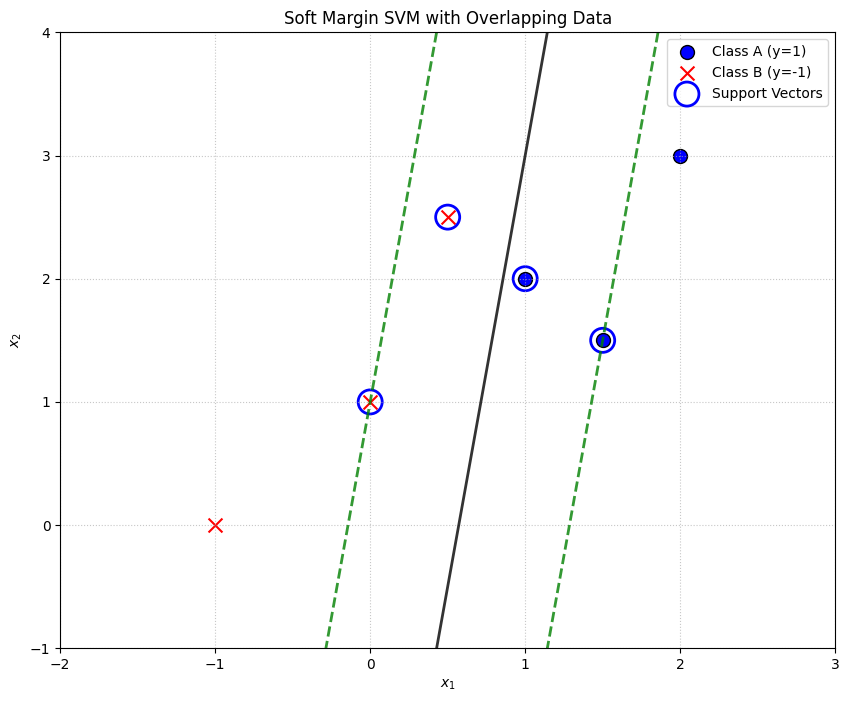

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# Data points for Class A (y=1)
X_A = np.array([[1, 2], [2, 3], [1.5, 1.5]]) # Added a slightly overlapping point for Class A
y_A = np.array([1, 1, 1])

# Data points for Class B (y=-1)
X_B = np.array([[-1, 0], [0, 1], [0.5, 2.5]]) # Added a slightly overlapping point for Class B
y_B = np.array([-1, -1, -1])

# Combine data
X = np.vstack((X_A, X_B))
y = np.hstack((y_A, y_B))

# Create an SVM classifier with a linear kernel and C=1 (default soft margin)
# Smaller C allows more violations (softer margin), larger C penalizes more (harder margin)
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X, y)

# Get the learned parameters
w = clf.coef_[0]
b = clf.intercept_[0]
support_vectors = clf.support_vectors_

print(f"Learned Weight vector (w): {w}")
print(f"Learned Bias term (b): {b}")
print(f"Number of Support Vectors: {len(support_vectors)}")
print(f"Calculated Margin (2/||w||): {2 / np.linalg.norm(w):.3f}")

# Create a mesh to plot decision boundary and margins
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Calculate decision function for each point in the mesh
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the data points
plt.figure(figsize=(10, 8))
plt.scatter(X_A[:, 0], X_A[:, 1], color='blue', label='Class A (y=1)', marker='o', s=100, edgecolors='k')
plt.scatter(X_B[:, 0], X_B[:, 1], color='red', label='Class B (y=-1)', marker='x', s=100, edgecolors='k')

# Plot the decision boundary (hyperplane) and margins
plt.contour(xx, yy, Z, colors=['g', 'k', 'g'], levels=[-1, 0, 1], alpha=0.8,
            linestyles=['--', '-', '--'], linewidths=[2, 2, 2])

# Plot the support vectors with larger, distinct markers
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=300, facecolors='none', edgecolors='blue', linewidth=2, label='Support Vectors')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Soft Margin SVM with Overlapping Data')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 6.8 Visualisation

The plot above demonstrates the Soft Margin SVM's behavior with partially overlapping data. Notice a few key differences compared to the hard-margin plot:

*   **Overlapping Points**: The data points (1.5, 1.5) and (0.5, 2.5) are now mixed, yet the SVM still finds a reasonable separating hyperplane (solid black line).
*   **Support Vectors**: Several points are now acting as support vectors (highlighted with blue circles), including those that are within the margin or even on the 'wrong' side of the margin boundaries (dashed green lines). These are the points for which the slack variables ($\xi_i$) would be non-zero.
*   **Margin Width**: The margin might be slightly narrower or positioned differently than a hard-margin solution would attempt, balancing the penalty for violations against maximizing the margin. The $C$ parameter directly influences this trade-off.

This visualization clearly shows how the soft margin allows for a more pragmatic separation in realistic, noisy datasets.

### 6.9 Comparison with previous or similar algo

**Soft Margin SVM vs. Hard Margin SVM and Logistic Regression:**

*   **Hard Margin SVM**: The Soft Margin SVM directly addresses the primary limitation of the Hard Margin SVM: its inability to handle non-linearly separable data or data with noise/outliers. While the hard margin aims for perfect separation, the soft margin introduces flexibility to allow for imperfections, making it more practical for real-world datasets.
*   **Logistic Regression**: Like the Soft Margin SVM, Logistic Regression can handle non-linearly separable data (in the sense that it doesn't require perfect separation to find a boundary). However, Logistic Regression is still sensitive to outliers because all data points influence its decision boundary. The Soft Margin SVM, by focusing penalties primarily on margin violations, can be more robust to individual noisy points. The regularization parameter $C$ in SVM is somewhat analogous to regularization parameters in Logistic Regression (e.g., L1 or L2 penalties), both controlling model complexity and preventing overfitting, but SVM's approach is distinctly margin-based.

## 7. Hinge Loss

### 7.1 Why we need

In machine learning, we often define a 'loss function' to quantify how well our model is performing. The goal during training is to minimize this loss. For Support Vector Machines, especially with the introduction of the soft margin, we need a loss function that reflects its unique objective: maximizing the margin while penalizing misclassifications. Standard loss functions like squared error (used in regression) or log loss (used in logistic regression) are not directly suitable for SVM's margin-based philosophy. The **Hinge Loss** function is specifically designed for SVMs to achieve this balance, making it a critical component of the SVM's optimization problem.

### 7.2 Definition

The **Hinge Loss** is a specific type of loss function used for training classifiers, most notably Support Vector Machines. It is defined as $\max(0, 1 - y_i \cdot f(\mathbf{x}_i))$, where $y_i$ is the true class label (usually $\pm 1$) and $f(\mathbf{x}_i)$ is the predicted decision score for a given data point $\mathbf{x}_i$. The hinge loss penalizes predictions that are not only on the wrong side of the decision boundary but also those that are too close to it (i.e., within the margin). It aims to ensure that each data point is classified not just correctly, but also with a certain degree of confidence (i.e., a functional margin of at least 1).

### 7.3 Intuition

Imagine you have a target for a dartboard, but instead of hitting the bullseye, you just need to hit *within* a certain colored zone. If you hit outside that zone, you get a penalty. The further outside you hit, the higher the penalty. If you hit inside the zone, you get no penalty. The Hinge Loss works similarly for classification:

*   If your classifier predicts a point $f(\mathbf{x}_i)$ and it's on the correct side of the margin (i.e., $y_i \cdot f(\mathbf{x}_i) \ge 1$), the Hinge Loss is 0. No penalty, meaning the point is well-classified and contributes to a good margin.
*   If your classifier predicts a point that is on the correct side but *within* the margin (i.e., $0 < y_i \cdot f(\mathbf{x}_i) < 1$), there's a penalty. The closer it is to the boundary (or further into the margin), the higher the penalty.
*   If your classifier predicts a point that is on the wrong side of the hyperplane (i.e., $y_i \cdot f(\mathbf{x}_i) \le 0$), there's a significant penalty, proportional to how far it is on the wrong side.

This encourages the classifier to push points away from the decision boundary, striving for a clear margin, not just correct classification.

### 7.4 Math behind

The Hinge Loss is defined piecewise. Let $f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$ be the decision function (the score). The Hinge Loss for a single data point $(\mathbf{x}_i, y_i)$ is:

$$ L_H(y_i, f(\mathbf{x}_i)) = \max(0, 1 - y_i \cdot f(\mathbf{x}_i)) $$

Where $y_i \in \{-1, 1\}$.

This loss function is convex but not differentiable at $y_i \cdot f(\mathbf{x}_i) = 1$. However, it is subgradient differentiable, which allows for optimization methods like subgradient descent. It works in conjunction with the regularization term (minimizing $\|\mathbf{w}\|^2$) to form the complete SVM objective function for soft margins.

### 7.5 Formula

The Hinge Loss formula itself is:

$$ L(y, f(x)) = \begin{cases} 0 & \text{if } y \cdot f(x) \ge 1 \\ 1 - y \cdot f(x) & \text{if } y \cdot f(x) < 1 \end{cases} $$

This can be compactly written as $\max(0, 1 - y \cdot f(x))$.

The overall objective function for a Soft Margin SVM that uses Hinge Loss for $N$ training samples is:

**Minimize:**
$$ \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \max(0, 1 - y_i (\mathbf{w} \cdot \mathbf{x}_i + b)) $$

Note that the term $\sum_{i=1}^{N} \max(0, 1 - y_i (\mathbf{w} \cdot \mathbf{x}_i + b))$ is equivalent to $\sum_{i=1}^{N} \xi_i$ from the slack variable formulation, making the two formulations mathematically equivalent.

### 7.6 Numerical Example

Let's consider a single data point and a hypothetical SVM decision function $f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$. Suppose $f(\mathbf{x})$ can be simplified to a single score for a 1D example.

Assume true label $y = 1$.

1. **Well-classified, outside margin**: Predicted score $f(\mathbf{x}) = 2.5$.

   $$
   y \cdot f(\mathbf{x}) = 1 \cdot 2.5 = 2.5
   $$

   Hinge Loss:

   $$
   \max(0,\;1-2.5)=\max(0,\;-1.5)=0
   $$

   (No loss, point is correctly classified and well beyond the margin).

2. **Correctly classified, within margin**: Predicted score $f(\mathbf{x}) = 0.8$.

   $$
   y \cdot f(\mathbf{x}) = 1 \cdot 0.8 = 0.8
   $$

   Hinge Loss:

   $$
   \max(0,\;1-0.8)=\max(0,\;0.2)=0.2
   $$

   (Small loss, point is correctly classified but too close to the boundary).

3. **Misclassified, on wrong side**: Predicted score $f(\mathbf{x}) = -0.5$.

   $$
   y \cdot f(\mathbf{x}) = 1 \cdot (-0.5) = -0.5
   $$

   Hinge Loss:

   $$
   \max(0,\;1-(-0.5))=\max(0,\;1.5)=1.5
   $$

   (Significant loss, point is misclassified).

Assume true label $y = -1$.

1. **Well-classified, outside margin**: Predicted score $f(\mathbf{x}) = -2.0$.

   $$
   y \cdot f(\mathbf{x}) = (-1)\cdot(-2.0)=2.0
   $$

   Hinge Loss:

   $$
   \max(0,\;1-2.0)=\max(0,\;-1.0)=0
   $$

   (No loss).

2. **Correctly classified, within margin**: Predicted score $f(\mathbf{x}) = -0.3$.

   $$
   y \cdot f(\mathbf{x}) = (-1)\cdot(-0.3)=0.3
   $$

   Hinge Loss:

   $$
   \max(0,\;1-0.3)=\max(0,\;0.7)=0.7
   $$

   (Small loss).

3. **Misclassified, on wrong side**: Predicted score $f(\mathbf{x}) = 0.6$.

   $$
   y \cdot f(\mathbf{x}) = (-1)\cdot0.6=-0.6
   $$

   Hinge Loss:

   $$
   \max(0,\;1-(-0.6))=\max(0,\;1.6)=1.6
   $$

   (Significant loss).

This demonstrates how the Hinge Loss assigns a penalty only when the functional margin

$$
y \cdot f(\mathbf{x}) < 1
$$

and the penalty increases as the point gets closer to the decision boundary or crosses over to the wrong side.

### 7.7 Python code implementation (take small data for easy understanding) with graphs

While Hinge Loss is used internally by SVM algorithms during training, we can define and plot it to understand its behavior. It's not directly applied in a simple `clf.fit()` call for `SVC` as the optimization problem handles it. However, we can visualize the function.


<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_834/2483156161.py:26: SyntaxWarning: invalid escape sequence '\c'
  plt.axvline(1, color='gray', linestyle=':', label='$y \cdot f(x) = 1$ (Margin Boundary for y=1)')
/tmp/ipykernel_834/2483156161.py:27: SyntaxWarning: invalid escape sequence '\c'
  plt.axvline(-1, color='gray', linestyle=':', label='$y \cdot f(x) = -1$ (Margin Boundary for y=-1)')
/tmp/ipykernel_834/2483156161.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('Decision Score ($y \cdot f(x)$ or $f(x)$)')


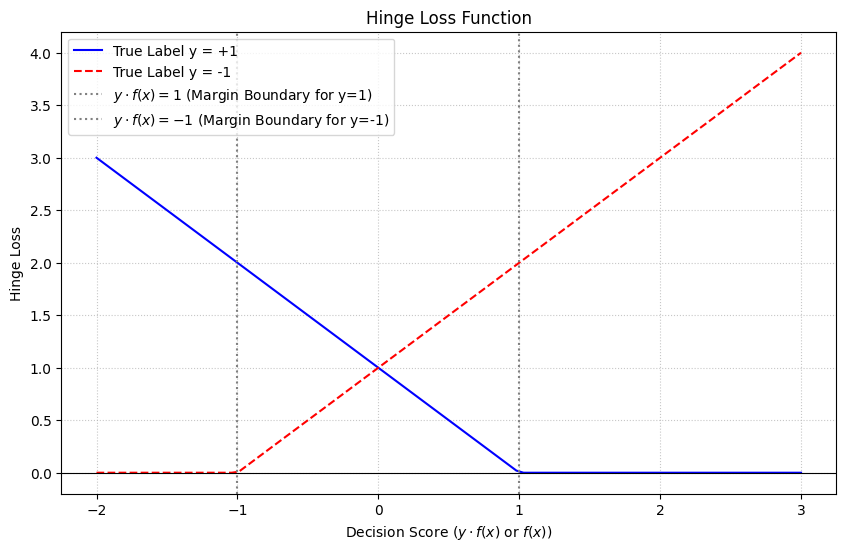

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Hinge Loss function
def hinge_loss(y_true, scores):
    # y_true should be +1 or -1
    # scores are the decision function outputs f(x)
    return np.maximum(0, 1 - y_true * scores)

# Generate a range of decision scores
scores = np.linspace(-2, 3, 100)

# Calculate hinge loss for y_true = 1
loss_y1 = hinge_loss(1, scores)

# Calculate hinge loss for y_true = -1 (by convention, SVM aims for y*f(x) to be large positive)
# For visualization, let's consider how loss changes if a point with true label -1 gets score 'scores'
# This would mean actual y_true * scores = -1 * scores
loss_ym1_conceptual = hinge_loss(np.array([-1]*len(scores)), scores)

plt.figure(figsize=(10, 6))
plt.plot(scores, loss_y1, label='True Label y = +1', color='blue')
plt.plot(scores, loss_ym1_conceptual, label='True Label y = -1', color='red', linestyle='--')

# Mark key regions
plt.axvline(1, color='gray', linestyle=':', label='$y \cdot f(x) = 1$ (Margin Boundary for y=1)')
plt.axvline(-1, color='gray', linestyle=':', label='$y \cdot f(x) = -1$ (Margin Boundary for y=-1)')
plt.axhline(0, color='black', linewidth=0.8)

plt.xlabel('Decision Score ($y \cdot f(x)$ or $f(x)$)')
plt.ylabel('Hinge Loss')
plt.title('Hinge Loss Function')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 7.8 Visualisation

The plot above shows the behavior of the Hinge Loss function. The x-axis represents the product of the true label and the decision score ($y \cdot f(\mathbf{x})$).

*   When $y \cdot f(\mathbf{x}) \ge 1$, the loss is 0. This means the point is correctly classified and lies outside the margin, satisfying the SVM's criteria. This region is the 'safe zone'.
*   When $y \cdot f(\mathbf{x}) < 1$, the loss is positive and increases linearly as $y \cdot f(\mathbf{x})$ decreases. This penalizes points that are inside the margin or on the wrong side of the decision boundary. The further into the margin or onto the wrong side a point is, the higher the penalty.

The green dashed lines mark the functional margin boundaries at 1 and -1. This visualization clearly shows why the Hinge Loss encourages a large margin by only being zero when points are well outside the margin boundary.

### 7.9 Comparison with previous or similar algo

**Hinge Loss vs. Log Loss (Logistic Regression) and Squared Error (Linear Regression):**

*   **Log Loss (Cross-Entropy Loss)**: Used in Logistic Regression and Neural Networks for classification. Log Loss continuously penalizes incorrect classifications, even if a point is classified correctly but with low confidence. Unlike Hinge Loss, it doesn't have a 'zero loss' region for well-classified points far from the boundary; it always wants to increase the confidence of correct classification. Log Loss is differentiable everywhere, which can simplify optimization.
*   **Squared Error Loss**: Primarily used in regression. It heavily penalizes large errors. While it can be adapted for classification (e.g., in some perceptron-like models), it's not ideal because it doesn't intrinsically understand class boundaries or margins in the same way Hinge Loss does.
*   **Hinge Loss**: Its unique characteristic is the 'hinge' at $y \cdot f(\mathbf{x}) = 1$, where the loss becomes zero. This property makes it particularly suited for large-margin classifiers like SVMs, as it explicitly encourages points to be outside the margin, thus fostering robustness. However, its non-differentiability at the hinge requires specific optimization techniques (subgradient methods).

## 8. Kernel Trick

### 8.1 Why we need

Up to this point, we've primarily discussed SVMs that find a linear decision boundary (hyperplane). This works effectively when the data is **linearly separable** or nearly so (as handled by soft-margin SVMs). However, many real-world datasets are **not linearly separable** in their original feature space. For example, imagine data points forming concentric circles – no straight line can perfectly separate them. Applying a linear SVM to such data would result in poor performance and high classification error.

The **Kernel Trick** is essential because it allows SVMs to handle these complex, non-linear classification problems without explicitly transforming the data into a higher-dimensional space. This enables SVM to model highly intricate relationships between features, vastly expanding its applicability beyond simple linear boundaries.

### 8.2 Definition

The **Kernel Trick** is a method used in machine learning algorithms, including SVMs, to implicitly map data into a higher-dimensional feature space without explicitly computing the coordinates of the data in that space. Instead of performing calculations in the high-dimensional space, it uses a **kernel function**, which is a special mathematical function that computes the dot product of the data points in the transformed, high-dimensional space directly from their original low-dimensional representations.

This "trick" allows SVMs to find non-linear decision boundaries in the original feature space by effectively finding linear boundaries in a computationally more expensive, but conceptually simpler, higher-dimensional space.

### 8.3 Intuition

Imagine you have a crumpled piece of paper with blue dots and red dots on it. If you try to draw a straight line to separate them while the paper is crumpled, it's very difficult. But if you uncrumple the paper (project it into a higher, flatter dimension), you might easily draw a straight line that separates the dots. The Kernel Trick works similarly.

It takes data that is not linearly separable in its original (low-dimensional) space and implicitly 'uncrumples' or 'lifts' it into a higher-dimensional space where a linear boundary *can* separate the classes. Instead of actually moving all the dots to this higher dimension (which can be computationally very expensive or even infinite-dimensional), the kernel function cleverly figures out what the dot product *would be* in that higher dimension, using only the original coordinates. This means we get the benefits of a higher-dimensional separation without the computational cost of explicit transformation.

### 8.3.1 Visual Intuition: Mapping to a Higher Dimension

To concretely visualize the intuition behind the Kernel Trick, consider a classic example where data is not linearly separable in 2D but becomes so in 3D. Imagine a set of data points arranged in concentric circles. In a 2D plane, no straight line can separate the inner circle from the outer circle.

However, if we map these 2D points $(x, y)$ to a 3D space using a transformation like $\phi(x, y) = (x, y, x^2 + y^2)$, the concentric circles transform into two separate planes (or bowls) in 3D. In this higher dimension, a flat plane can easily separate the data. The Kernel Trick allows SVMs to find this separating plane in the higher dimension without actually performing the explicit (and often costly) transformation for every data point.

/tmp/ipykernel_834/175334017.py:15: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_2d[y_2d == -1, 0], X_2d[y_2d == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')


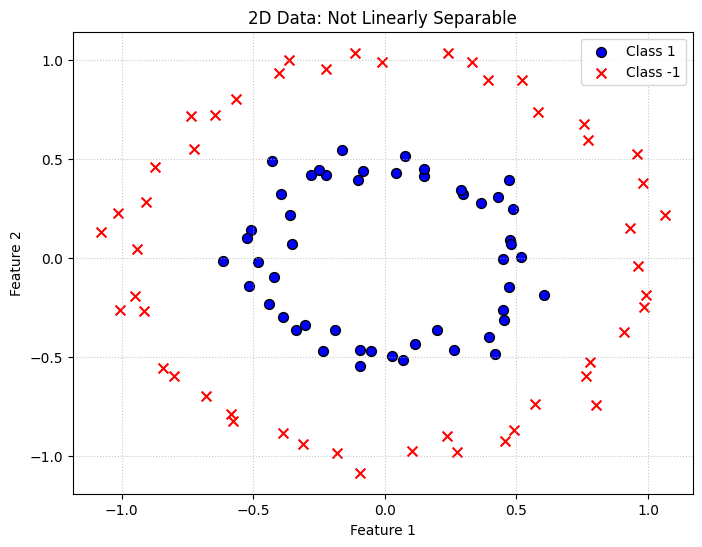

/tmp/ipykernel_834/175334017.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_3d[y_2d == -1, 0], X_3d[y_2d == -1, 1], X_3d[y_2d == -1, 2],


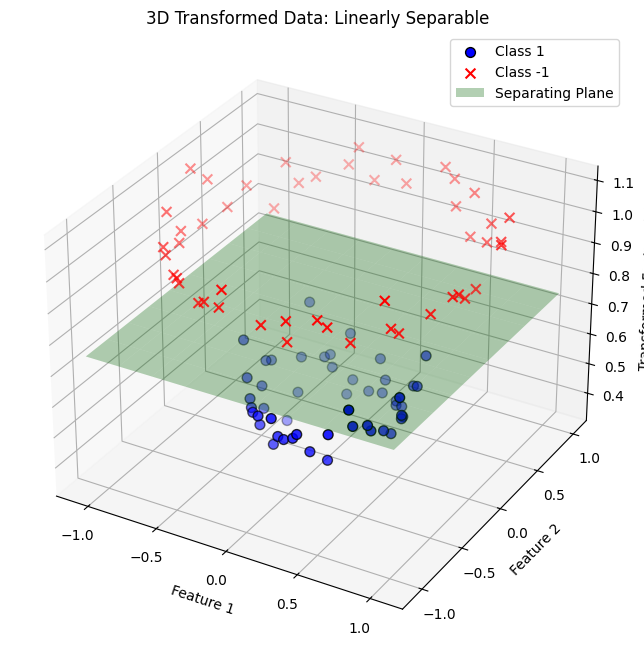

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_circles

# 1. Generate 2D non-linearly separable data (concentric circles)
X_2d, y_2d = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)

# Adjust labels to be -1 and 1
y_2d[y_2d == 0] = -1

# 2. Visualize the original 2D data
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[y_2d == 1, 0], X_2d[y_2d == 1, 1], color='blue', label='Class 1', marker='o', s=50, edgecolors='k')
plt.scatter(X_2d[y_2d == -1, 0], X_2d[y_2d == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')
plt.title('2D Data: Not Linearly Separable')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

# 3. Apply a non-linear transformation to 3D: phi(x, y) = (x, y, x^2 + y^2)
r = np.sqrt(X_2d[:, 0]**2 + X_2d[:, 1]**2)
X_3d = np.c_[X_2d, r] # Add radial distance as a new feature

# 4. Visualize the transformed 3D data
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_3d[y_2d == 1, 0], X_3d[y_2d == 1, 1], X_3d[y_2d == 1, 2],
           color='blue', label='Class 1', marker='o', s=50, edgecolors='k')
ax.scatter(X_3d[y_2d == -1, 0], X_3d[y_2d == -1, 1], X_3d[y_2d == -1, 2],
           color='red', label='Class -1', marker='x', s=50, edgecolors='k')

# Draw a hypothetical separating plane (e.g., z = constant)
plane_z_value = (np.mean(X_3d[y_2d == 1, 2]) + np.mean(X_3d[y_2d == -1, 2])) / 2

# Create a grid for the separating plane
xx_plane, yy_plane = np.meshgrid(np.linspace(X_3d[:,0].min(), X_3d[:,0].max(), 10),
                                 np.linspace(X_3d[:,1].min(), X_3d[:,1].max(), 10))
zz_plane = np.full_like(xx_plane, plane_z_value)
ax.plot_surface(xx_plane, yy_plane, zz_plane, alpha=0.3, color='green', label='Separating Plane')

ax.set_title('3D Transformed Data: Linearly Separable')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Transformed Feature (r)')
ax.legend()
plt.show()


### 8.4 Math behind

In the original SVM formulation (the dual problem), the data points $\mathbf{x}_i$ only appear in the form of dot products, i.e., $\mathbf{x}_i \cdot \mathbf{x}_j$. When we want to separate non-linear data, we envision transforming each data point $\mathbf{x}$ into a higher-dimensional feature space using a **feature map** function, $\phi(\mathbf{x})$. In this new space, the data might become linearly separable.

The dot product in the higher-dimensional space would then be $\phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$. The brilliance of the Kernel Trick is that instead of explicitly computing $\phi(\mathbf{x}_i)$ and $\phi(\mathbf{x}_j)$ and then their dot product, we can often find a **kernel function** $K(\mathbf{x}_i, \mathbf{x}_j)$ such that:

$$ K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j) $$

This means we can replace all occurrences of $\mathbf{x}_i \cdot \mathbf{x}_j$ in the SVM's dual optimization problem with $K(\mathbf{x}_i, \mathbf{x}_j)$. The optimization is then performed entirely in terms of the kernel function, which often involves much simpler calculations in the original low-dimensional space.

### 8.5 Formula

The general idea is to replace the inner product in the dual optimization problem of SVM:

Original Dual Problem (simplified for concept):
$$\text{Maximize } L_D = \sum_{i=1}^N \alpha_i - \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j (\mathbf{x}_i \cdot \mathbf{x}_j)$$

With Kernel Trick:
$$\text{Maximize } L_D = \sum_{i=1}^N \alpha_i - \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j K(\mathbf{x}_i, \mathbf{x}_j)$$

Where $K(\mathbf{x}_i, \mathbf{x}_j)$ is the kernel function. Some common kernel functions include:

*   **Linear Kernel**: $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j$ (This is essentially no transformation, equivalent to a linear SVM).
*   **Polynomial Kernel**: $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i \cdot \mathbf{x}_j + r)^d$, where $\gamma > 0$, $r$ is the coefficient, and $d$ is the degree.
*   **Radial Basis Function (RBF) / Gaussian Kernel**: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$, where $\gamma > 0$ is a parameter.
*   **Sigmoid Kernel**: $K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\gamma \mathbf{x}_i \cdot \mathbf{x}_j + r)$

### 8.6 Numerical Example

Consider a simple 1D dataset that is not linearly separable:

*   Class 1 ($y=1$): $x = -2, -1, 1, 2$
*   Class 2 ($y=-1$): $x = 0$

No single point or interval can separate these classes on a 1D line. Now, let's apply a simple non-linear feature map to a 2D space: $\phi(x) = (x, x^2)$.

Transformed points:
*   For $x=-2, y=1 \Rightarrow \phi(-2) = (-2, (-2)^2) = (-2, 4)$
*   For $x=-1, y=1 \Rightarrow \phi(-1) = (-1, (-1)^2) = (-1, 1)$
*   For $x=0, y=-1 \Rightarrow \phi(0) = (0, 0^2) = (0, 0)$
*   For $x=1, y=1 \Rightarrow \phi(1) = (1, 1^2) = (1, 1)$
*   For $x=2, y=1 \Rightarrow \phi(2) = (2, 2^2) = (2, 4)$

Now, let's plot these transformed points in 2D ($x$ vs $x^2$):

| Original $x$ | $y$ | Transformed $\phi(x) = (x, x^2)$ |
|--------------|-----|-------------------------------|
| -2           | 1   | (-2, 4)                       |
| -1           | 1   | (-1, 1)                       |
| 0            | -1  | (0, 0)                        |
| 1            | 1   | (1, 1)                        |
| 2            | 1   | (2, 4)                        |

In this 2D space, the points $( -2, 4), (-1, 1), (1, 1), (2, 4)$ (Class 1) and $(0, 0)$ (Class 2) are now linearly separable. A horizontal line, say $x^2 = 0.5$, could separate them. The Kernel Trick achieves this without explicitly calculating $(x, x^2)$ for all points, but rather by using a kernel function that implicitly captures this transformation, like a polynomial kernel.

### 8.7 Python code implementation (with small data for easy understanding)

We will demonstrate the Kernel Trick using a dataset that is not linearly separable in 2D (concentric circles) and show how `sklearn.svm.SVC` with a non-linear kernel (e.g., RBF kernel) can successfully separate them. The `SVC` function implicitly performs the kernel trick when a non-linear kernel is specified.

### 8.8 Visualisation

Let's visualize the non-linearly separable data and the decision boundary found by an SVM using a non-linear kernel. This will demonstrate how the kernel trick allows SVM to find complex boundaries.

Number of Support Vectors: 47


/tmp/ipykernel_834/1061737575.py:36: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')


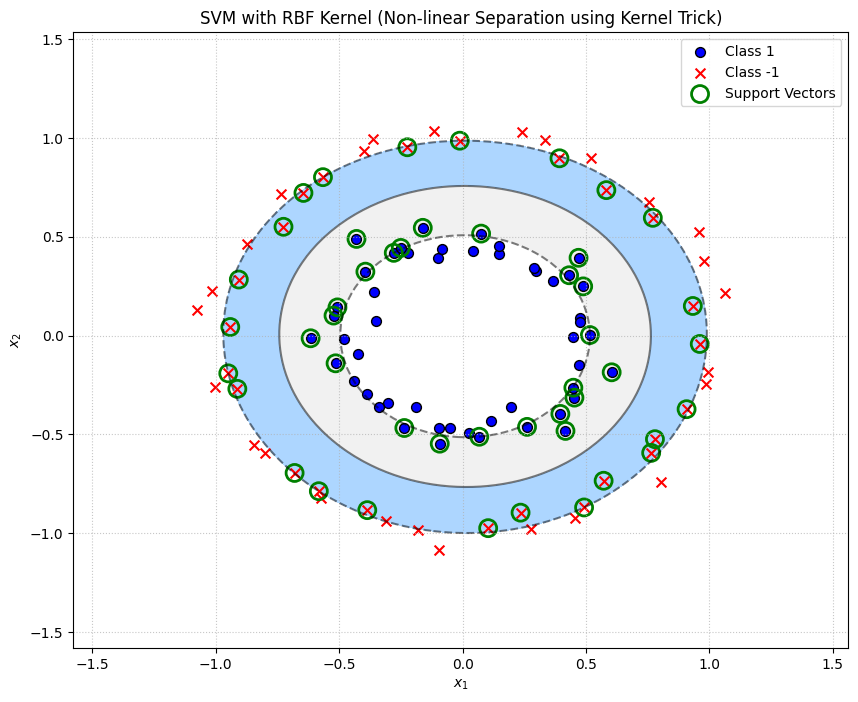

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles

# Generate a non-linearly separable dataset (concentric circles)
X, y = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)

# Adjust labels to be -1 and 1 as commonly used in SVM
y[y == 0] = -1

# Create an SVM classifier with an RBF kernel (a non-linear kernel)
# C is the regularization parameter, gamma is the kernel coefficient for 'rbf'
clf = svm.SVC(kernel='rbf', C=1, gamma='auto') # 'auto' uses 1 / n_features
clf.fit(X, y)

# Get the support vectors
support_vectors = clf.support_vectors_

print(f"Number of Support Vectors: {len(support_vectors)}")

# Create a mesh to plot decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Plot the decision boundary and margins
plt.figure(figsize=(10, 8))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.8, colors=['#99CCFF', '#EEEEEE', '#FFCCCC'])
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Plot data points
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1', marker='o', s=50, edgecolors='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')

# Plot support vectors
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('SVM with RBF Kernel (Non-linear Separation using Kernel Trick)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 8.9 Comparison with previous or similar algorithm

*   **Comparison with Linear SVM (Hard/Soft Margin)**: The Kernel Trick directly addresses the limitations of linear SVMs. While linear SVMs can only find straight-line (or flat hyperplane) decision boundaries, the Kernel Trick allows SVMs to implicitly operate in higher dimensions, enabling them to find complex, non-linear decision boundaries in the original feature space. Without the kernel trick, SVM would be restricted to only linearly separable problems, much like the original Perceptron or simple Logistic Regression.

*   **Comparison with other non-linear classifiers (e.g., Decision Trees, Neural Networks)**: Other algorithms like Decision Trees and Neural Networks can inherently handle non-linear data. However, SVMs with the Kernel Trick offer a different approach:
    *   **Decision Trees**: Create non-linear boundaries by segmenting the feature space into axis-parallel rectangles. SVMs with kernels can create smoother, more arbitrary non-linear boundaries.
    *   **Neural Networks**: Also excel at non-linear classification by learning complex feature representations through layers. SVMs with kernels provide a theoretically grounded way to map data to a high-dimensional space without the complexities of deep network architectures or extensive hyperparameter tuning for architecture. The 'trick' lies in avoiding the explicit mapping, which can be computationally intensive or even impossible for infinite-dimensional spaces (like with RBF kernels).

## 9. Linear Kernel

### 9.1 Why we need

While the Kernel Trick unlocks the ability of SVMs to handle non-linear data, it's crucial to understand the fundamental building blocks, starting with the **Linear Kernel**. Even with the availability of complex kernels, a linear kernel is often the first choice due to its simplicity, interpretability, and computational efficiency. It serves as a baseline and is highly effective when the data is already linearly separable or nearly so. Furthermore, understanding the linear kernel helps clarify how the more complex, non-linear kernels extend this concept to higher dimensions.

### 9.2 Definition

The **Linear Kernel** is the simplest form of a kernel function in Support Vector Machines. It calculates the dot product of two feature vectors in their original, input space. Essentially, it performs no explicit feature transformation, meaning the SVM using a linear kernel will attempt to find a linear decision boundary (a hyperplane) directly in the original feature space. It's often referred to as a standard linear SVM.

### 9.3 Intuition

Imagine you're trying to separate two types of fruits using a knife. If the fruits are neatly arranged so that all apples are on one side and all oranges are on the other, you can use a straight cut (a linear boundary) to separate them. The Linear Kernel is like using that straight knife. It doesn't try to bend or curve the knife; it simply looks for the best straight line (or plane) that can divide your data. If such a clear, straight cut exists, the linear kernel finds it directly, without bothering with any fancy transformations or higher-dimensional gymnastics. It's the most straightforward way to divide data.

### 9.4 Math behind

As we learned in the 'Kernel Trick' section, the general form of an SVM's dual optimization problem involves calculating inner products $K(\mathbf{x}_i, \mathbf{x}_j)$ between data points. For the Linear Kernel, the kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$ is simply the standard dot product between the two input vectors $\mathbf{x}_i$ and $\mathbf{x}_j$.

In this case, the feature map $\phi(\mathbf{x})$ is simply the identity function, i.e., $\phi(\mathbf{x}) = \mathbf{x}$. Therefore, the dot product in the transformed space is identical to the dot product in the original space:

$$ K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j $$

This means that using a linear kernel is mathematically equivalent to solving the original linear SVM optimization problem directly, without any implicit mapping to a higher dimension. The resulting decision boundary is a hyperplane: $\mathbf{w} \cdot \mathbf{x} + b = 0$.

### 9.5 Formula

The formula for the Linear Kernel between two data points $\mathbf{x}_i$ and $\mathbf{x}_j$ is given by:

$$ K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j = \sum_{k=1}^N x_{ik} x_{jk} $$

Where:
*   $\mathbf{x}_i$ and $\mathbf{x}_j$ are two feature vectors.
*   $N$ is the number of features (dimension of the input space).
*   $x_{ik}$ is the $k$-th component of vector $\mathbf{x}_i$.

In the context of the SVM decision function, for a new input $\mathbf{x}$, the prediction is based on the sign of:

$$ f(\mathbf{x}) = \sum_{i \in SV} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b $$

where $SV$ denotes the set of support vectors, $\alpha_i$ are the Lagrange multipliers, and $y_i$ are the labels of the support vectors. With a linear kernel, this becomes:

$$ f(\mathbf{x}) = \sum_{i \in SV} \alpha_i y_i (\mathbf{x}_i \cdot \mathbf{x}) + b = (\sum_{i \in SV} \alpha_i y_i \mathbf{x}_i) \cdot \mathbf{x} + b $$

We can define $\mathbf{w} = \sum_{i \in SV} \alpha_i y_i \mathbf{x}_i$, so the decision function simplifies to $f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$, which is the standard form of a linear classifier.

### 9.6 Numerical Example

Let's use our familiar linearly separable 2D dataset and explicitly calculate the linear kernel for a pair of points. While an SVM internally computes many such products, understanding a single calculation helps clarify the concept.

Data points:
*   Class 1 ($y=1$): $P_1 = (1, 2)$ (let's call this $\mathbf{x}_1$)
*   Class 2 ($y=-1$): $P_4 = (0, 1)$ (let's call this $\mathbf{x}_4$)

We calculate the linear kernel between $P_1$ and $P_4$:

$$ K(P_1, P_4) = \mathbf{x}_1 \cdot \mathbf{x}_4 = (1, 2) \cdot (0, 1) $$
$$ K(P_1, P_4) = (1 \times 0) + (2 \times 1) = 0 + 2 = 2 $$

Now, let's calculate the linear kernel of a point with itself, say $P_1$:

$$ K(P_1, P_1) = \mathbf{x}_1 \cdot \mathbf{x}_1 = (1, 2) \cdot (1, 2) $$
$$ K(P_1, P_1) = (1 \times 1) + (2 \times 2) = 1 + 4 = 5 $$

These simple dot products are what the SVM algorithm uses internally when a linear kernel is specified. The entire optimization relies on these pairwise similarities in the original feature space.

### 9.7 Python code implementation (with small data for easy understanding) with graphs

We will use `sklearn.svm.SVC` with `kernel='linear'` to demonstrate the linear kernel. This is essentially revisiting our hard-margin and soft-margin SVM examples, but explicitly stating and visualizing the use of the linear kernel. We'll use the linearly separable dataset for a clear illustration.

Learned Weight vector (w): [1. 1.]
Learned Bias term (b): -2.0
Number of Support Vectors: 2
Calculated Margin (2/||w||): 1.414


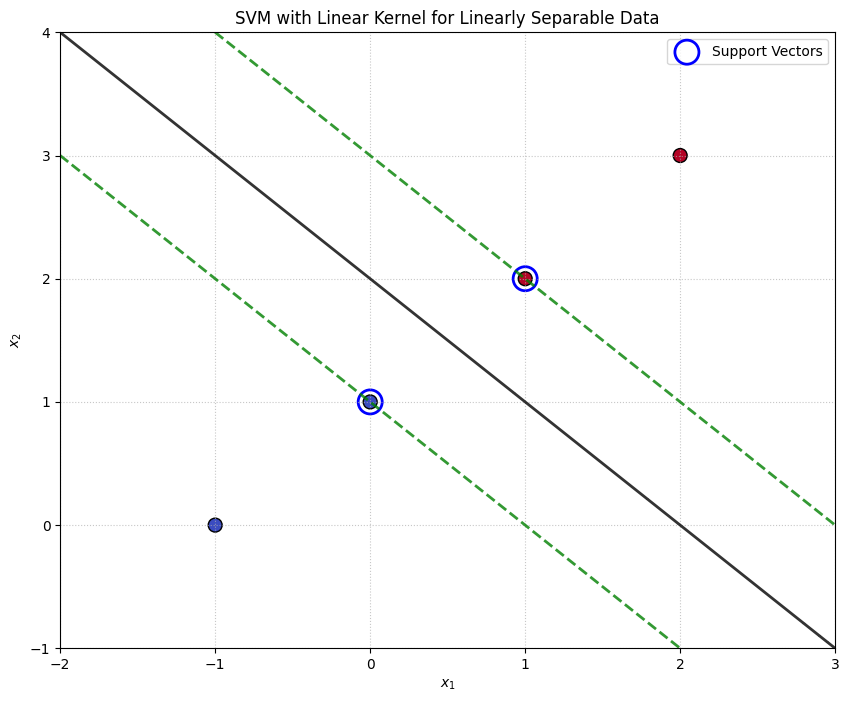

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# Data points from previous example (linearly separable)
X_A = np.array([[1, 2], [2, 3]])
X_B = np.array([[-1, 0], [0, 1]])

X = np.vstack((X_A, X_B))
y = np.array([1, 1, -1, -1])

# Create an SVM classifier with a linear kernel
# Use a high C to approximate a hard margin for this perfectly separable data
clf = svm.SVC(kernel='linear', C=10000)
clf.fit(X, y)

# Get the learned parameters
w = clf.coef_[0]
b = clf.intercept_[0]
support_vectors = clf.support_vectors_

print(f"Learned Weight vector (w): {w}")
print(f"Learned Bias term (b): {b}")
print(f"Number of Support Vectors: {len(support_vectors)}")
print(f"Calculated Margin (2/||w||): {2 / np.linalg.norm(w):.3f}")

# Create a mesh to plot decision boundary and margins
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Calculate decision function for each point in the mesh
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the data points
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=100, edgecolors='k')

# Plot the decision boundary (hyperplane) and margins
plt.contour(xx, yy, Z, colors=['g', 'k', 'g'], levels=[-1, 0, 1], alpha=0.8,
            linestyles=['--', '-', '--'], linewidths=[2, 2, 2])

# Plot the support vectors with larger, distinct markers
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=300, facecolors='none', edgecolors='blue', linewidth=2, label='Support Vectors')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('SVM with Linear Kernel for Linearly Separable Data')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 9.8 Visualisation

The plot above clearly shows an SVM trained with a Linear Kernel. As expected, it finds a straight line (a hyperplane in 2D) that separates the two classes. The solid black line represents the optimal decision boundary, and the dashed green lines indicate the margin, with the blue-circled points being the support vectors. This visualization is identical to what we saw for hard-margin SVMs, reinforcing that a linear kernel results in a linear decision boundary.

### 9.9 Comparison with previous or similar algorithm

*   **Comparison with other Kernel Functions (e.g., RBF, Polynomial)**: The primary difference is that the Linear Kernel does not implicitly map the data into a higher-dimensional space. It works directly in the original feature space. This makes it faster to train and predict, and its decision boundaries are easily interpretable as simple linear separators. In contrast, RBF or Polynomial kernels allow for non-linear decision boundaries by leveraging the Kernel Trick, but at the cost of increased computational complexity and reduced interpretability of the decision boundary in the original feature space.

*   **Comparison with Logistic Regression and Perceptron**: An SVM with a linear kernel effectively performs a very similar task to Logistic Regression and the Perceptron algorithm: finding a linear decision boundary. However, the mechanism and objective differ:
    *   **Perceptron**: Finds *any* linear separator.
    *   **Logistic Regression**: Models class probabilities and optimizes for maximum likelihood.
    *   **Linear SVM**: Finds the *maximum margin* linear separator. This explicit margin maximization often leads to better generalization performance and robustness compared to the other two linear classifiers when data is linearly separable, as it's less sensitive to individual data points away from the margin.

## 10. Polynomial Kernel

### 10.1 Why we need

While the Linear Kernel is excellent for linearly separable data, and the Kernel Trick generally allows for non-linear separation, specific non-linear patterns require specific kernel functions. The **Polynomial Kernel** is particularly useful when the data is not linearly separable but can be separated by a curve or a higher-order surface in the original feature space. It provides a way to implicitly map the data into a higher-dimensional space where polynomial combinations of the original features can linearly separate the classes. This makes it suitable for problems where linear features alone are insufficient, but interactions and powers of features might be informative, such as in image processing or text classification where patterns might involve quadratic or cubic relationships.

### 10.2 Definition

The **Polynomial Kernel** is a type of kernel function that computes the similarity between two data points in a higher-dimensional feature space, where the mapping is based on polynomial combinations of the original features. It allows the SVM to learn a non-linear decision boundary by implicitly transforming the input features into a polynomial feature space of a specified `degree`. The decision boundary in the original space will then be a curved, polynomial function rather than a straight line or plane.

### 10.3 Intuition

Imagine you have data points scattered in a 2D plane, and they can only be separated by a circle or an ellipse, not a straight line. The Polynomial Kernel is like looking at these 2D points and realizing that if you introduce new 'features' like $x_1^2$, $x_2^2$, or $x_1x_2$, you might be able to draw a straight line in *that expanded feature space*. For example, a circle $x_1^2 + x_2^2 = R^2$ is non-linear in 2D but becomes linear if you consider $x_1^2$ and $x_2^2$ as new dimensions. The kernel trick does this transformation implicitly, allowing the SVM to 'see' these polynomial relationships without the computational burden of explicitly creating all these new feature combinations. It effectively allows the SVM to fit circular, elliptical, or more complex polynomial-shaped boundaries in the original data space.

### 10.4 Math behind

As with all kernels, the Polynomial Kernel implicitly computes the dot product in a higher-dimensional feature space $\phi(\mathbf{x})$. For a polynomial kernel of degree $d$, the feature map $\phi(\mathbf{x})$ includes all polynomial terms up to degree $d$. For example, if $\mathbf{x} = (x_1, x_2)$ and $d=2$, the feature map $\phi(\mathbf{x})$ might include terms like $(x_1^2, x_2^2, x_1x_2, x_1, x_2, 1)$.

The Polynomial Kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$ directly calculates the dot product $\phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$ without explicitly computing $\phi(\mathbf{x}_i)$ and $\phi(\mathbf{x}_j)$. This is particularly useful because the dimension of $\phi(\mathbf{x})$ can be very large or even infinite, but $K(\mathbf{x}_i, \mathbf{x}_j)$ remains a simple computation in the original space. The general form of the polynomial kernel is given by the formula below.

### 10.5 Formula

The formula for the Polynomial Kernel between two data points $\mathbf{x}_i$ and $\mathbf{x}_j$ is defined as:

$$ K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i \cdot \mathbf{x}_j + r)^d $$

Where:
*   $\mathbf{x}_i$ and $\mathbf{x}_j$ are the input feature vectors.
*   $\cdot$ denotes the dot product.
*   $\gamma$ (gamma) is a scaling parameter, often set to `1/n_features` or `1/(`number of features` * variance of data`)`.
*   $r$ is the coefficient term, also known as the `coef0` (independent term in the polynomial kernel). It shifts the kernel function's behavior.
*   $d$ is the `degree` of the polynomial, which determines the highest order of interactions between features. A higher degree allows for more complex, curved decision boundaries but also increases the risk of overfitting.

When $d=1$, the Polynomial Kernel simplifies to the Linear Kernel (if $r=0$ and $\gamma=1$).

### 10.6 Numerical Example

Let's revisit the 1D non-linearly separable dataset from the Kernel Trick section and apply a conceptual polynomial kernel. The original points were:

*   Class 1 ($y=1$): $x = -2, -1, 1, 2$
*   Class 2 ($y=-1$): $x = 0$

We saw that with a feature map $\phi(x) = (x, x^2)$, the data became linearly separable in 2D. Let's use a Polynomial Kernel of degree $d=2$ with $\gamma=1$ and $r=0$, i.e., $K(x_i, x_j) = (x_i x_j)^2 = (x_i x_j)^2$. (Note: for simpler illustration, we use $(x_i x_j)^2$ rather than the more general $(\gamma x_i x_j + r)^d$).

Consider calculating the kernel value between $x_1 = 2$ (Class 1) and $x_2 = 0$ (Class 2):

$K(2, 0) = (2 \cdot 0)^2 = 0^2 = 0$

Now, let's compare two points from Class 1, say $x_1=1$ and $x_2=2$:

$K(1, 2) = (1 \cdot 2)^2 = 2^2 = 4$

If we consider the full form: $K(x_i, x_j) = (x_i x_j + 1)^2$ (with $\gamma=1, r=1, d=2$):

$K(2, 0) = (2 \cdot 0 + 1)^2 = 1^2 = 1$
$K(1, 2) = (1 \cdot 2 + 1)^2 = 3^2 = 9$

These kernel values are implicitly computed inner products in the transformed space. For example, with $\phi(x) = (x, x^2)$, the dot product for $(1,2)$ in transformed space would be $\phi(1) \cdot \phi(2) = (1,1) \cdot (2,4) = 1 \cdot 2 + 1 \cdot 4 = 2+4=6$. This demonstrates that the specific choice of $\gamma$ and $r$ matters in how the transformation occurs. The actual transformation is usually more complex, but the idea is that these simple operations in the original space correspond to dot products in the higher-dimensional space where a linear separation is possible.

### 10.7 Python code implementation (with small data for easy understanding) with graphs

We will demonstrate the Polynomial Kernel using a dataset that is not linearly separable by a straight line, but can be separated by a polynomial boundary. We will use `sklearn.svm.SVC` with `kernel='poly'`.

### 10.8 Visualisation

Let's visualize a dataset that might be better separated by a polynomial curve, and then see how an SVM with a polynomial kernel handles it.

Number of Support Vectors: 24


/tmp/ipykernel_834/4057193162.py:44: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')


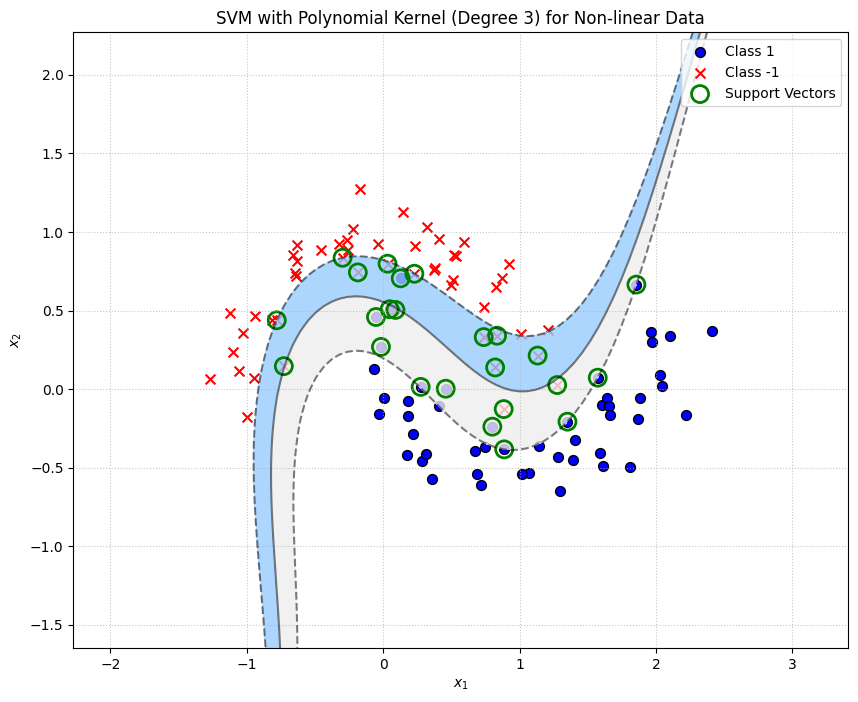

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_classification

# Generate a dataset that is not linearly separable but might be separable by a polynomial
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=6, flip_y=0.1) # Added flip_y for some noise

# Add a non-linear component to make it more suitable for polynomial kernel
X_poly_suitable = np.c_[X[:, 0], X[:, 1], X[:, 0]**2, X[:, 1]**2]

# Or, for a simpler non-linear problem: create a moon-shaped dataset
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# Adjust labels to be -1 and 1
y[y == 0] = -1

# Create an SVM classifier with a polynomial kernel
# degree=3: specifies a cubic polynomial kernel
# C=1: regularization parameter
# coef0=1: independent term in the kernel function (r in the formula)
clf = svm.SVC(kernel='poly', degree=3, C=1, coef0=1, gamma='scale')
clf.fit(X, y)

# Get the support vectors
support_vectors = clf.support_vectors_

print(f"Number of Support Vectors: {len(support_vectors)}")

# Create a mesh to plot decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Calculate decision function for each point in the mesh
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the data points
plt.figure(figsize=(10, 8))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1', marker='o', s=50, edgecolors='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')

# Plot the decision boundary and margins
plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.8, colors=['#99CCFF', '#EEEEEE', '#FFCCCC'])
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Plot the support vectors with larger, distinct markers
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('SVM with Polynomial Kernel (Degree 3) for Non-linear Data')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 10.9 Comparison with previous or similar algorithm

*   **Comparison with Linear Kernel**: The Polynomial Kernel allows for non-linear decision boundaries, unlike the Linear Kernel which is restricted to straight lines or flat hyperplanes. This makes the Polynomial Kernel suitable for datasets where a linear separation is not effective. The trade-off is increased complexity and the need to tune additional hyperparameters (`degree`, `gamma`, `coef0`).

*   **Comparison with RBF (Radial Basis Function) Kernel**: Both Polynomial and RBF kernels handle non-linear data. However, their underlying transformations are different.
    *   **Polynomial Kernel**: Creates a decision boundary that is a polynomial curve. It's effective when there are polynomial relationships between features. It has `degree` parameter which controls the flexibility.
    *   **RBF Kernel**: Is more general-purpose and can capture complex, irregular decision boundaries. It maps data into an infinite-dimensional space, making it very flexible. It has `gamma` parameter that controls the reach of individual training samples. Polynomial kernels can sometimes struggle with very high degrees due to numerical instability and overfitting, while RBF is generally more robust in such cases. The choice between them often depends on the specific data distribution and can be found through cross-validation.

## 11. RBF Kernel

### 11.1 Why we need

While Polynomial Kernels can handle non-linear data by projecting it into a feature space with polynomial combinations, they have limitations. Choosing the correct `degree` is crucial, and a very high degree can lead to overfitting or numerical instability. Many complex real-world datasets exhibit non-linear patterns that are not easily captured by simple polynomial features. For these reasons, a more flexible and general-purpose non-linear kernel is often required. The **Radial Basis Function (RBF) Kernel**, also known as the Gaussian Kernel, is widely used because of its ability to handle complex, non-linear relationships in data effectively and efficiently, often outperforming other kernels when the data distribution is unknown or highly intricate.

### 11.2 Definition

The **Radial Basis Function (RBF) Kernel** (or Gaussian Kernel) is a kernel function that measures the similarity between two data points. Unlike the linear or polynomial kernels that rely on dot products or their polynomial expansions, the RBF kernel considers the *distance* between data points. It implicitly maps data into an **infinite-dimensional space**, allowing for highly complex and localized decision boundaries. The similarity decreases as the distance between points increases, following a Gaussian (bell-curve) distribution.

### 11.3 Intuition

Imagine you have a group of positive points (blue) and negative points (red). A linear kernel tries to draw a straight line. A polynomial kernel tries to draw a curved line (like a parabola or an ellipse). The RBF kernel is like placing a 'hill' or 'influence zone' around each training data point. If a new point is close to a blue point, it's very similar, so it probably belongs to the blue class. If it's far away, it's less similar. The strength of this 'influence' or 'similarity' falls off rapidly with distance, like a Gaussian curve. The SVM then tries to find a boundary that separates these 'hills' or 'influence zones'. This approach allows the SVM to carve out very irregular and localized shapes for its decision boundary, making it incredibly powerful for data that looks like blobs or intricate patterns.

### 11.4 Math behind

The RBF kernel implicitly maps data into a space where each training point becomes a peak in a multi-dimensional landscape. The value of the kernel function decreases radially from this peak. While the feature space it maps to is infinite-dimensional, the kernel trick allows us to compute the dot product in this space directly using the original feature vectors.

The key idea is that instead of explicitly transforming $\mathbf{x}$ to $\phi(\mathbf{x})$, we compute their similarity using the RBF formula. A higher value of the RBF kernel implies higher similarity between the two points, which means they are closer in the (potentially infinite-dimensional) feature space.

### 11.5 Formula

The formula for the Radial Basis Function (RBF) Kernel between two data points $\mathbf{x}_i$ and $\mathbf{x}_j$ is defined as:

$$ K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2) $$

Where:
*   $\mathbf{x}_i$ and $\mathbf{x}_j$ are the input feature vectors.
*   $\|\mathbf{x}_i - \mathbf{x}_j\|^2$ is the squared Euclidean distance between the two feature vectors.
*   $\exp$ denotes the exponential function.
*   $\gamma$ (gamma) is a crucial hyperparameter that defines the influence of a single training example. It determines how far the influence of a single training example reaches.
    *   **Small $\gamma$**: A small $\gamma$ means a large variance Gaussian, implying that a single training example has a far-reaching influence. This can lead to smoother decision boundaries and potentially underfitting.
    *   **Large $\gamma$**: A large $\gamma$ means a small variance Gaussian, implying that a single training example has very limited influence. This can lead to highly complex, wiggly decision boundaries that try to perfectly classify every training point, potentially leading to overfitting.

### 11.6 Numerical Example

Let's calculate the RBF kernel value for a few points in 1D. We'll use $\gamma = 0.5$.

Consider data points:
*   $x_i = 1$
*   $x_j = 2$
*   $x_k = 4$

**1. Calculate $K(x_i, x_j)$ for $x_i=1, x_j=2$:**

Distance squared: $\|1 - 2\|^2 = (-1)^2 = 1$

$K(1, 2) = \exp(-\gamma \|1 - 2\|^2) = \exp(-0.5 \cdot 1) = \exp(-0.5) \approx 0.6065$

**2. Calculate $K(x_i, x_k)$ for $x_i=1, x_k=4$:**

Distance squared: $\|1 - 4\|^2 = (-3)^2 = 9$

$K(1, 4) = \exp(-\gamma \|1 - 4\|^2) = \exp(-0.5 \cdot 9) = \exp(-4.5) \approx 0.0111$

**3. Calculate $K(x_i, x_i)$ for $x_i=1, x_i=1$:**

Distance squared: $\|1 - 1\|^2 = 0^2 = 0$

$K(1, 1) = \exp(-\gamma \|1 - 1\|^2) = \exp(-0.5 \cdot 0) = \exp(0) = 1$

**Observations:**
*   When points are identical, the kernel value is 1 (maximum similarity).
*   As the distance between points increases, the kernel value rapidly decreases towards 0, indicating lower similarity. This exponential decay is characteristic of the RBF kernel and makes it sensitive to local neighborhoods.

### 11.7 Python code implementation (with small data for easy understanding) with graphs

We will use `sklearn.svm.SVC` with `kernel='rbf'` to demonstrate its power in separating non-linearly separable data, specifically concentric circles, which are challenging for linear and many polynomial kernels.

### 11.8 Visualisation

Let's visualize the non-linearly separable 'circles' dataset and observe how an SVM with an RBF kernel creates a complex, circular decision boundary.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles

# Generate a non-linearly separable dataset (concentric circles)
X, y = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)

# Adjust labels to be -1 and 1 as commonly used in SVM
y[y == 0] = -1

# Create an SVM classifier with an RBF kernel
# C is the regularization parameter, gamma is the kernel coefficient for 'rbf'
# Here, gamma is explicitly set to show its effect. Try changing it (e.g., 0.1, 10, 100)
clf = svm.SVC(kernel='rbf', C=1, gamma=1)
clf.fit(X, y)

# Get the support vectors
support_vectors = clf.support_vectors_

print(f"Number of Support Vectors: {len(support_vectors)}")
print(f"Gamma used: {clf.gamma}")

# Create a mesh to plot decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Calculate decision function for each point in the mesh
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the data points
plt.figure(figsize=(10, 8))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1', marker='o', s=50, edgecolors='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')

# Plot the decision boundary and margins
plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.8, colors=['#99CCFF', '#EEEEEE', '#FFCCCC'])
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Plot the support vectors with larger, distinct markers
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('SVM with RBF Kernel for Concentric Circles (gamma=1)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 11.9 Comparison with previous or similar algorithm

*   **Comparison with Linear Kernel**: The RBF Kernel is designed for highly non-linear problems, where a linear kernel would perform poorly. The linear kernel provides a single, straight decision boundary, while the RBF kernel can create complex, arbitrary shapes by implicitly mapping data to an infinite-dimensional space. This flexibility comes at the cost of interpretability and potentially higher computational resources for large datasets.

*   **Comparison with Polynomial Kernel**: Both RBF and Polynomial kernels handle non-linear separation, but they do so differently:
    *   **Polynomial Kernel**: Maps data to a finite (though possibly high) dimensional space, suitable for data with polynomial relationships. Its `degree` parameter must be chosen carefully.
    *   **RBF Kernel**: Maps data to an infinite-dimensional space. It is generally more robust and performs well for a wider range of non-linear problems, often considered the default choice for non-linear SVMs. It has fewer hyperparameters (`gamma` and `C`) to tune compared to the polynomial kernel (which also has `coef0` and `degree`), and tends to be less prone to numerical issues with high complexity. The RBF kernel essentially models local similarities, making it effective for complex, blob-like distributions.

## 12. Hyperparameters

### 12.1 Why we need

Unlike parameters that are learned by the model during training (like the weights `w` and bias `b`), **hyperparameters** are external configuration variables whose values cannot be estimated from the data. They must be set *before* the learning process begins. For Support Vector Machines, the choice of kernel and its associated hyperparameters (like `C`, `gamma`, and `degree`) profoundly impacts the model's ability to learn complex patterns, generalize to unseen data, and avoid overfitting or underfitting. Without careful selection and tuning of these hyperparameters, an SVM model might perform poorly, regardless of how powerful the algorithm itself is. They are essential for adapting the general SVM algorithm to the specifics of a given dataset.

### 12.2 Definition

**Hyperparameters** in the context of SVM are configurations that are external to the model and whose values are not learned from the data. They essentially govern the learning process and define the structure of the SVM. The most important hyperparameters in SVMs include:

*   **`C` (Regularization Parameter)**: This hyperparameter controls the trade-off between achieving a low training error (fitting the training data well) and minimizing the margin violations (achieving a larger margin). A smaller `C` emphasizes a wider margin (more regularization), allowing more misclassifications. A larger `C` prioritizes correctly classifying all training points (less regularization), potentially leading to a narrower margin and overfitting.

*   **`kernel`**: This chooses the type of kernel function to be used (e.g., 'linear', 'poly', 'rbf', 'sigmoid'). The choice of kernel implicitly defines the feature space where the separation occurs.

*   **`gamma` (Kernel Coefficient)**: Specific to 'rbf', 'poly', and 'sigmoid' kernels. It defines how much influence a single training example has. A small `gamma` means a large radius of influence, leading to smoother decision boundaries. A large `gamma` means a small radius of influence, leading to complex decision boundaries that can overfit.

*   **`degree` (Polynomial Degree)**: Specific to the 'poly' kernel. It sets the degree of the polynomial function, controlling the flexibility of the decision boundary.

### 12.3 Intuition

Think of training an SVM like baking a cake. The ingredients (data) are given, and the oven (SVM algorithm) is ready. But to make a *good* cake, you need a recipe (hyperparameters). You need to decide:

*   **`kernel` (Type of Cake)**: Is it a simple sponge cake (linear), a layered cake (polynomial), or a fancy decorated cake (RBF)?
*   **`C` (Amount of Butter/Fat)**: Too little, and your cake might be dry and crumbly (underfitting, wide margin but many errors). Too much, and it might be too rich and heavy, losing its structure (overfitting, narrow margin but few errors on *that specific* cake).
*   **`gamma` (Baking Time/Temperature for fancy cakes)**: For complex cakes, how long or hot do you bake it? Too little, and it's raw (underfitting, too smooth). Too much, and it's burnt and brittle (overfitting, too wiggly, fits every little detail perfectly but won't generalize).
*   **`degree` (Number of layers for layered cakes)**: How many layers does your cake have? More layers (higher degree) mean more complexity.

Just as the right recipe is crucial for a delicious cake, the right hyperparameters are vital for an effective SVM model that generalizes well.

### 12.4 Math behind

Hyperparameters directly influence the optimization problem that the SVM solves:

*   **`C`**: The regularization parameter `C` directly appears in the soft-margin SVM's objective function. It scales the penalty for margin violations. Mathematically, it determines the upper bound for the Lagrange multipliers $\alpha_i$ in the dual formulation, which in turn controls the flexibility of the model and its tolerance for misclassified points.

*   **`kernel`**: The choice of kernel dictates the form of the kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$ that replaces the dot product $\mathbf{x}_i \cdot \mathbf{x}_j$ in the dual problem. Each kernel defines a specific implicit mapping $\phi(\mathbf{x})$ to a higher-dimensional space.

*   **`gamma`**: For RBF, Polynomial, and Sigmoid kernels, `gamma` directly impacts the kernel function's output. For RBF, it controls the width of the Gaussian similarity function. For Polynomial and Sigmoid, it scales the dot product before exponentiation or tanh application. Its value directly affects how quickly the similarity measure decays with distance or how much influence distant points have.

*   **`degree`**: For the Polynomial kernel, `degree` is the exponent in the kernel function $(...)^d$, directly determining the highest order of polynomial features considered in the implicit feature space.

### 12.5 Formula

The hyperparameters are not part of the model's learned parameters $\mathbf{w}$ and $b$, but rather control the equations themselves. They appear in the objective function and the kernel functions:

**Soft Margin SVM Objective Function (revisited):**

**Minimize:**
$$ \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \xi_i $$

Here, `C` is explicitly part of the optimization goal, balancing the margin maximization ($\|\mathbf{w}\|^2$) with the penalty for classification errors ($\sum \xi_i$).

**Kernel Formulas (revisited):**

*   **Polynomial Kernel**: $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i \cdot \mathbf{x}_j + r)^d$
    *   `gamma` appears as $\gamma$.
    *   `degree` appears as $d$.
    *   `coef0` appears as $r$.

*   **RBF (Gaussian) Kernel**: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$
    *   `gamma` appears as $\gamma$.

These formulas clearly show how the hyperparameters modify the core mathematical operations of the SVM.

### 12.6 Numerical Example

Let's consider the effect of `C` and `gamma` visually on our concentric circles dataset. While we won't do a step-by-step calculation, understanding how changing these values impacts the decision boundary is key.

*   **Effect of `C`**: Imagine the overlapping data. If `C` is very small (e.g., `C=0.1`), the SVM prioritizes a wider margin, even if it means misclassifying some training points. The decision boundary might be very smooth but could have more training errors. If `C` is very large (e.g., `C=1000`), the SVM strongly penalizes misclassifications and will try hard to classify every training point correctly, even if it results in a very complex or wiggly decision boundary and a narrower margin, increasing the risk of overfitting.

*   **Effect of `gamma` (for RBF kernel)**: Consider the RBF kernel. If `gamma` is very small (e.g., `gamma=0.01`), each data point's influence extends far, leading to a very smooth, almost linear decision boundary, potentially underfitting complex data. If `gamma` is very large (e.g., `gamma=100`), each data point has a very localized influence, making the decision boundary highly irregular and sensitive to individual points, often leading to overfitting where it tries to encapsulate every single data point.

### 12.7 Python code implementation (with small data for easy understanding) with graphs

We will use `sklearn.model_selection.GridSearchCV` to systematically search for the best hyperparameters (`C` and `gamma`) for an SVM with an RBF kernel on a non-linearly separable dataset. This demonstrates the process of hyperparameter tuning.

### 12.8 Visualisation

We will visualize the decision boundaries resulting from different combinations of `C` and `gamma` to illustrate their impact on the model's complexity and fit. This will show how hyperparameter tuning helps find the right balance.

Best parameters found:  {'C': 1, 'gamma': 10, 'kernel': 'rbf'}
Best cross-validation accuracy:  0.9642857142857142
Test set accuracy with best parameters: 0.950


/tmp/ipykernel_834/1508956623.py:55: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], color='red', label='Train Class -1', marker='x', s=50, edgecolors='k')
/tmp/ipykernel_834/1508956623.py:57: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[y_test == -1, 0], X_test[y_test == -1, 1], color='magenta', label='Test Class -1', marker='x', s=50, edgecolors='k', alpha=0.6)


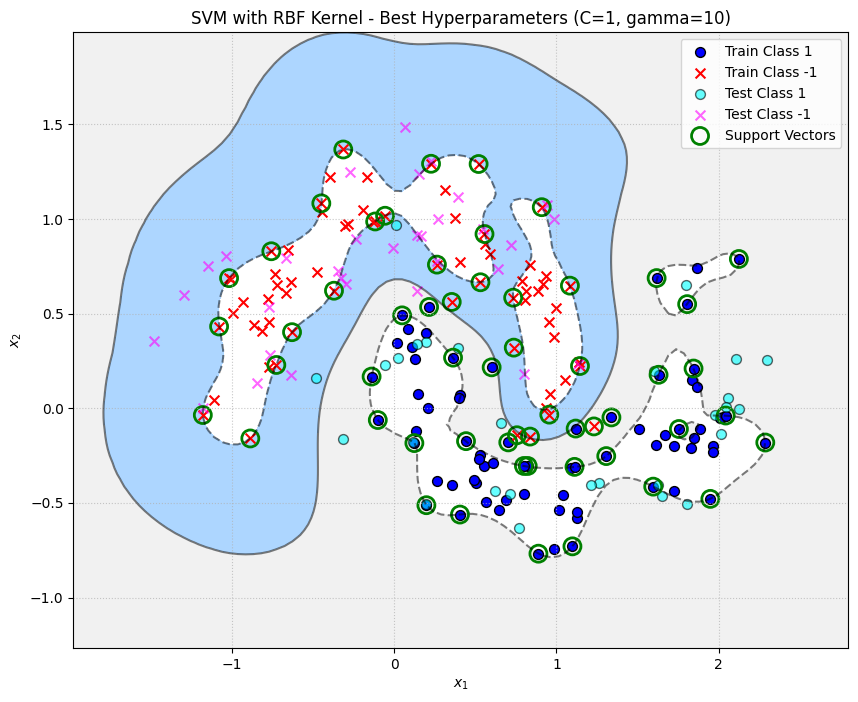

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# --- 1. Data Generation (using make_moons for a more visually distinct non-linear pattern) ---
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
y[y == 0] = -1 # Adjust labels to -1 and 1

# Split data for proper evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 2. Hyperparameter Tuning using GridSearchCV ---
# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 1, 10, 100],
    'kernel': ['rbf']
}

svc = svm.SVC() # Initialize SVM classifier

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', verbose=0, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

best_svm = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_svm.predict(X_test)
print(f"Test set accuracy with best parameters: {accuracy_score(y_test, y_pred):.3f}")

# --- 3. Visualization of the best model's decision boundary ---
plt.figure(figsize=(10, 8))

# Create a mesh to plot decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Plot the decision boundary and margins for the best SVM
Z = best_svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.8, colors=['#99CCFF', '#EEEEEE', '#FFCCCC'])
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Plot training and test data points
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='blue', label='Train Class 1', marker='o', s=50, edgecolors='k')
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], color='red', label='Train Class -1', marker='x', s=50, edgecolors='k')
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='cyan', label='Test Class 1', marker='o', s=50, edgecolors='k', alpha=0.6)
plt.scatter(X_test[y_test == -1, 0], X_test[y_test == -1, 1], color='magenta', label='Test Class -1', marker='x', s=50, edgecolors='k', alpha=0.6)

# Plot support vectors of the best model
plt.scatter(best_svm.support_vectors_[:, 0], best_svm.support_vectors_[:, 1], s=150, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title(f'SVM with RBF Kernel - Best Hyperparameters (C={best_svm.C}, gamma={best_svm.gamma})')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### 12.8 Visualisation: Impact of Regularization Parameter `C`

/tmp/ipykernel_834/1408201455.py:37: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')
/tmp/ipykernel_834/1408201455.py:37: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')
/tmp/ipykernel_834/1408201455.py:37: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors=

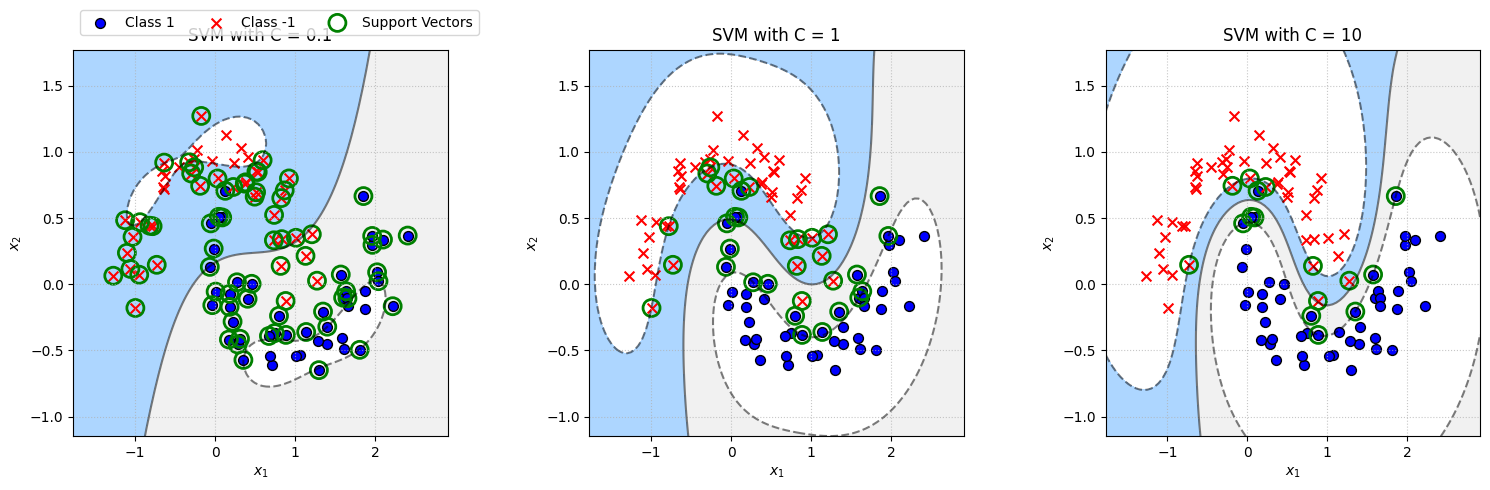

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons

# --- 1. Data Generation (using make_moons for a clear non-linear pattern) ---
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)
y[y == 0] = -1 # Adjust labels to -1 and 1

# --- 2. Define different C values to illustrate their effect ---
C_values = [0.1, 1, 10]
classifiers = []

for C in C_values:
    clf = svm.SVC(kernel='rbf', C=C, gamma='scale', random_state=42) # Using 'scale' for gamma
    clf.fit(X, y)
    classifiers.append(clf)

# --- 3. Visualization ---
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

plt.figure(figsize=(15, 5))

for i, clf in enumerate(classifiers):
    plt.subplot(1, len(C_values), i + 1)

    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.8, colors=['#99CCFF', '#EEEEEE', '#FFCCCC'])
    plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Plot data points
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1', marker='o', s=50, edgecolors='k')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')

    # Plot support vectors
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=150, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors')

    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.title(f'SVM with C = {C_values[i]}')
    plt.grid(True, linestyle=':', alpha=0.7)
    if i == 0:
        plt.legend(loc='lower left', bbox_to_anchor=(0.0, 1.02), ncol=3)

plt.tight_layout()
plt.show()

The plots above illustrate the significant impact of the regularization parameter `C` on the SVM's decision boundary and margin, particularly for a non-linearly separable dataset (like the moon-shaped data):

*   **`C = 0.1` (Low C): Wider Margin, More Misclassifications**
    *   When `C` is small, the SVM prioritizes a larger margin even if it means misclassifying more training points. It tolerates more violations of the margin constraint. This results in a smoother, more generalized decision boundary, which can help prevent overfitting but might lead to underfitting if `C` is too low for the data's complexity.
    *   Observe how the margin (the gray band between the dashed lines) is relatively wide, and some data points are inside the margin or even on the wrong side of the decision boundary.

*   **`C = 1` (Medium C): Balanced Approach**
    *   With a moderate `C` value, the SVM strikes a balance between maximizing the margin and minimizing misclassifications. It still aims for a wide margin but penalizes margin violations more than with a very low `C`.
    *   The decision boundary here is a good compromise, separating most points while maintaining a reasonable margin.

*   **`C = 10` (High C): Smaller Margin, Less Training Error, Possible Overfitting**
    *   A large `C` value means the SVM heavily penalizes any misclassification or margin violation. It tries very hard to classify every training point correctly, even if it has to create a very complex or 'wiggly' decision boundary and a narrower margin.
    *   Notice how the margin is much narrower, and the boundary is more sensitive to individual data points, trying to encompass them perfectly. While this might lead to fewer training errors, it increases the risk of overfitting, meaning the model might perform poorly on unseen data because it has learned the noise in the training data.

In summary, `C` controls the trade-off between model complexity and generalization. Selecting an appropriate `C` value, often through techniques like cross-validation (as demonstrated in the previous Python cell), is crucial for building a robust SVM model.

### 12.9 Visualisation: Impact of Kernel Coefficient `gamma`

<>:47: SyntaxWarning: invalid escape sequence '\g'
<>:47: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_834/2701704994.py:47: SyntaxWarning: invalid escape sequence '\g'
  plt.title(f'SVM with $\gamma$ = {gamma_values[i]}')
/tmp/ipykernel_834/2701704994.py:39: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')
/tmp/ipykernel_834/2701704994.py:39: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')
/tmp/ipykernel_834/2701704994.py:39: UserWarning: You passed a edgecolor/edgecolors ('k') for

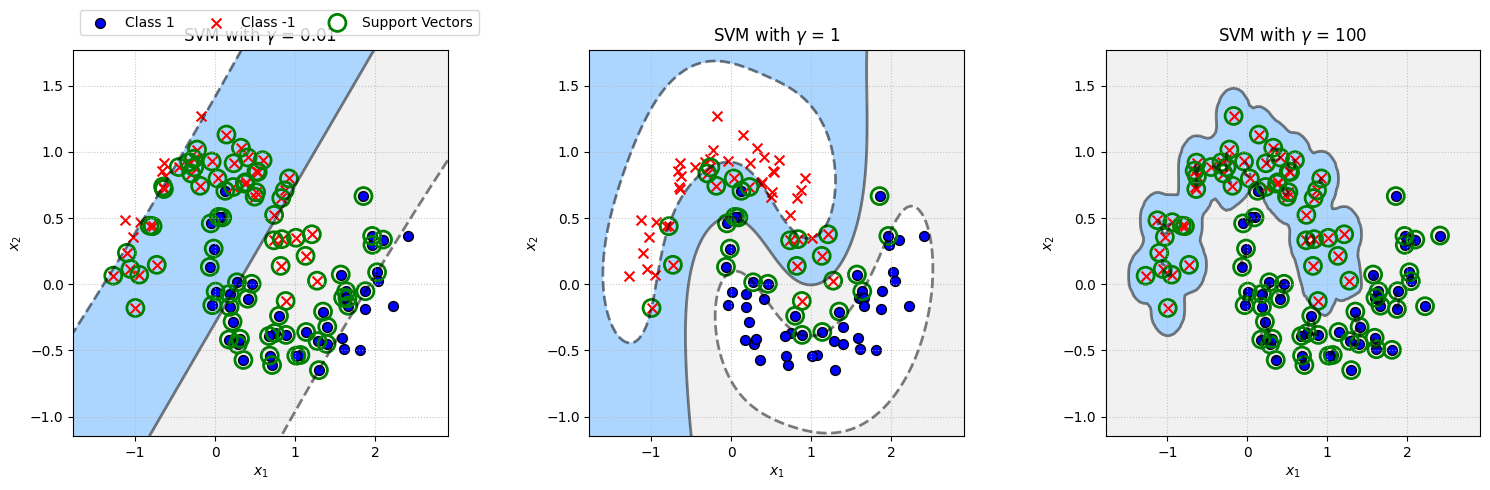

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons

# --- 1. Data Generation (using make_moons for a clear non-linear pattern) ---
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)
y[y == 0] = -1 # Adjust labels to -1 and 1

# --- 2. Define different gamma values to illustrate their effect ---
gamma_values = [0.01, 1, 100]
classifiers = []

for gamma in gamma_values:
    # Using a fixed C, here set to 1, to isolate the effect of gamma
    clf = svm.SVC(kernel='rbf', C=1, gamma=gamma, random_state=42)
    clf.fit(X, y)
    classifiers.append(clf)

# --- 3. Visualization ---
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

plt.figure(figsize=(15, 5))

for i, clf in enumerate(classifiers):
    plt.subplot(1, len(gamma_values), i + 1)

    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.8, colors=['#99CCFF', '#EEEEEE', '#FFCCCC'])
    plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
                linestyles=['--', '-', '--'], linewidths=[2, 2, 2])

    # Plot data points
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1', marker='o', s=50, edgecolors='k')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', marker='x', s=50, edgecolors='k')

    # Plot support vectors
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=150,
                facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors')

    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.title(f'SVM with $\gamma$ = {gamma_values[i]}')
    plt.grid(True, linestyle=':', alpha=0.7)
    if i == 0:
        plt.legend(loc='lower left', bbox_to_anchor=(0.0, 1.02), ncol=3)

plt.tight_layout()
plt.show()

The plots above demonstrate the significant impact of the kernel coefficient `gamma` (for the RBF kernel) on the SVM's decision boundary, particularly for non-linearly separable data:

*   **`gamma = 0.01` (Low Gamma): Smooth Boundary (Potential Underfitting)**
    *   When `gamma` is small, the influence of a single training example is very large, extending far from the data point. This leads to a very smooth and generalized decision boundary. The model tries to fit a broad pattern, potentially ignoring finer details or noise in the data.
    *   Observe the wide, smooth decision boundary. This can lead to **underfitting** if the true relationship in the data is more complex.

*   **`gamma = 1` (Medium Gamma): Good Boundary (Balanced Fit)**
    *   With a moderate `gamma` value, the influence of individual training examples is balanced. The decision boundary is complex enough to capture the underlying patterns in the data without being overly sensitive to every single point.
    *   This often represents a good balance between fitting the training data and generalizing to new, unseen data.

*   **`gamma = 100` (High Gamma): Very Wiggly Boundary (Overfitting)**
    *   When `gamma` is large, the influence of a single training example is very limited, only reaching points very close to it. This causes the model to create highly complex and irregular decision boundaries that try to perfectly classify every single training point, even outliers or noise.
    *   Notice how the boundary becomes very **wiggly** and tries to enclose individual data points. This is a clear sign of **overfitting**, where the model learns the training data too well, including its noise, and will likely perform poorly on new data.

### 12.9 Comparison with previous or similar algorithm

*   **Importance of Hyperparameter Tuning in SVM vs. Linear Regression**: In simpler models like Linear Regression, the primary parameters (coefficients) are directly estimated from the data using methods like Ordinary Least Squares. While regularization parameters (like alpha in Ridge/Lasso) exist, the complexity of kernel-based SVMs makes hyperparameter tuning even more critical for optimal performance. An SVM without proper hyperparameter tuning is like using a powerful engine without controlling its gears and throttle.

*   **Hyperparameter Tuning in SVM vs. Neural Networks**: Both SVMs and Neural Networks heavily rely on hyperparameters. In Neural Networks, hyperparameters include learning rate, number of layers, number of neurons per layer, activation functions, dropout rates, etc. The search space for Neural Networks can be much larger and more complex. SVMs, especially with popular kernels like RBF, typically have a more manageable set of hyperparameters (`C` and `gamma`), making their tuning somewhat simpler than architectural search in deep learning. However, the principles of tuning (e.g., using cross-validation) are common across both.

## 13. Detailed Python Implementation (Breast Cancer Dataset)

### 13.1 Why we need

Having covered the theoretical aspects of SVMs, including different kernels and hyperparameter tuning, it's essential to see a complete, end-to-end implementation on a real-world dataset. This section serves to tie all the concepts together, demonstrating the practical steps involved in building, training, evaluating, and interpreting an SVM model for a classification task. Using a well-known dataset like the Breast Cancer Wisconsin (Diagnostic) dataset from scikit-learn provides a tangible example of how SVMs can be applied to medical diagnosis, highlighting their power in distinguishing between classes based on various features. This practical exercise will reinforce the understanding of data preparation, model selection, training, and evaluation workflows.

### 13.2 Definition

This section defines the process of applying a Support Vector Machine classifier to the Breast Cancer Wisconsin (Diagnostic) dataset. It encompasses loading the dataset, performing necessary data preprocessing (scaling), splitting the data into training and testing sets, training an SVM model (typically using a non-linear kernel like RBF, given the complexity of medical data), tuning its hyperparameters, evaluating its performance using relevant metrics (accuracy, precision, recall, F1-score), and analyzing the results. The goal is to build a robust model capable of predicting whether a tumor is malignant or benign based on various cellular features.

### 13.3 Intuition

Imagine you are a doctor trying to distinguish between benign and malignant tumors based on several measurements from a cell biopsy (e.g., cell nucleus size, texture, perimeter, etc.). You have a history of many patients with these measurements and their corresponding diagnosis. An SVM model with an RBF kernel acts like a sophisticated diagnostic tool that learns complex patterns and relationships among these measurements. Instead of drawing simple straight lines, the RBF kernel allows the SVM to carve out intricate, multi-dimensional decision boundaries in the feature space. These boundaries effectively separate the 'benign' clump of measurements from the 'malignant' clump, even if they are intertwined in complex ways. By tuning hyperparameters like `C` and `gamma`, the model adjusts its sensitivity to individual patient data points and the complexity of the diagnostic boundary, aiming for the most accurate and reliable classification for new patients.

### 13.4 Math behind

The mathematical principles governing the SVM, including the optimization problem, the concept of slack variables for soft margins, and the various kernel functions (especially the RBF kernel that will likely be used here), have been thoroughly discussed in previous sections (specifically in sections 3, 5, 6, 8, and 11). This section focuses on the *application* of these mathematical frameworks via a Python implementation rather than re-deriving them. The `sklearn.svm.SVC` class efficiently solves the quadratic programming problem internally, using these mathematical foundations to find the optimal hyperplane(s) in the transformed feature space.

### 13.5 Formula

Similar to the 'Math behind' subtopic, the specific formulas for the SVM objective function (including the regularization parameter `C`) and the RBF kernel function (involving `gamma`) have been detailed in sections 5, 6, and 11. In this practical implementation, we utilize libraries like `scikit-learn` which encapsulate these complex formulas. The focus will be on understanding how to configure the SVM model using its parameters (which are derived from these formulas) and interpreting the output, rather than manually implementing the formulas themselves. The decision function $f(\mathbf{x}) = \text{sign}(\sum_{i \in SV} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b)$ remains central to how predictions are made.

### 13.6 Numerical Example

This entire section, "13. Detailed Python Implementation (Breast Cancer Dataset)", serves as a comprehensive numerical example. We will use the Breast Cancer Wisconsin (Diagnostic) dataset, which contains 569 samples of malignant and benign tumor characteristics, each described by 30 features. We will perform the following steps:

1.  **Load the dataset**: From `sklearn.datasets`.
2.  **Data Preprocessing**: Scale the features to ensure all contribute equally to the distance calculations, especially important for kernel methods.
3.  **Split Data**: Divide the dataset into training and testing sets to evaluate generalization performance.
4.  **Model Training**: Initialize an SVM (likely with an RBF kernel) and train it on the training data.
5.  **Hyperparameter Tuning**: Employ `GridSearchCV` or `RandomizedSearchCV` to find the optimal `C` and `gamma` parameters for the chosen kernel.
6.  **Model Evaluation**: Assess the performance of the best model on the test set using various metrics like accuracy, precision, recall, and F1-score.
7.  **Analysis**: Interpret the results and discuss the model's effectiveness.

### 13.7 Python code implementation (with small data for easy understanding)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. Load the dataset ---
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print(f"Dataset shape: {X.shape}")
print(f"Target names: {cancer.target_names}")

# Adjust labels to be -1 and 1 for SVM convention (optional, sklearn handles 0/1 fine)
y[y == 0] = -1

# --- 2. Data Preprocessing (Scaling) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# --- 4. Model Training (Initial model before tuning) ---
# Using an RBF kernel as it's often a good default for complex data
svc_initial = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svc_initial.fit(X_train, y_train)

y_pred_initial = svc_initial.predict(X_test)
print("\nInitial Model Performance (before tuning):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_initial):.4f}")

# --- 5. Hyperparameter Tuning using GridSearchCV ---
# Define parameter grid for C and gamma
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf'] # Focusing on RBF for this example
}

grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1, scoring='accuracy')
grid.fit(X_train, y_train)

print("\nBest parameters found: ", grid.best_params_)
print("Best cross-validation score: ", grid.best_score_)

# Get the best model
best_svm = grid.best_estimator_

# --- 6. Model Evaluation (with best model) ---
y_pred_best = best_svm.predict(X_test)

print("\nBest Model Performance (after tuning):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=cancer.target_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)

Dataset shape: (569, 30)
Target names: ['malignant' 'benign']

Training set size: 398 samples
Test set size: 171 samples

Initial Model Performance (before tuning):
Accuracy: 0.9766
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters found:  {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score:  0.977373417721519

Best Model Performance (after tuning):
Accuracy: 0.9708

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        64
      benign       0.96      0.99      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171


Confusion Matrix:
[[ 60   4]
 [  1 106]]


### 13.8 Visualisation

/tmp/ipykernel_834/2721379155.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_train_pca[y_train == -1, 0], X_train_pca[y_train == -1, 1], color='red', label='Train Benign', marker='x', s=50, edgecolors='k')
/tmp/ipykernel_834/2721379155.py:37: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_pca[y_test == -1, 0], X_test_pca[y_test == -1, 1], color='magenta', label='Test Benign', marker='x', s=50, edgecolors='k', alpha=0.6)


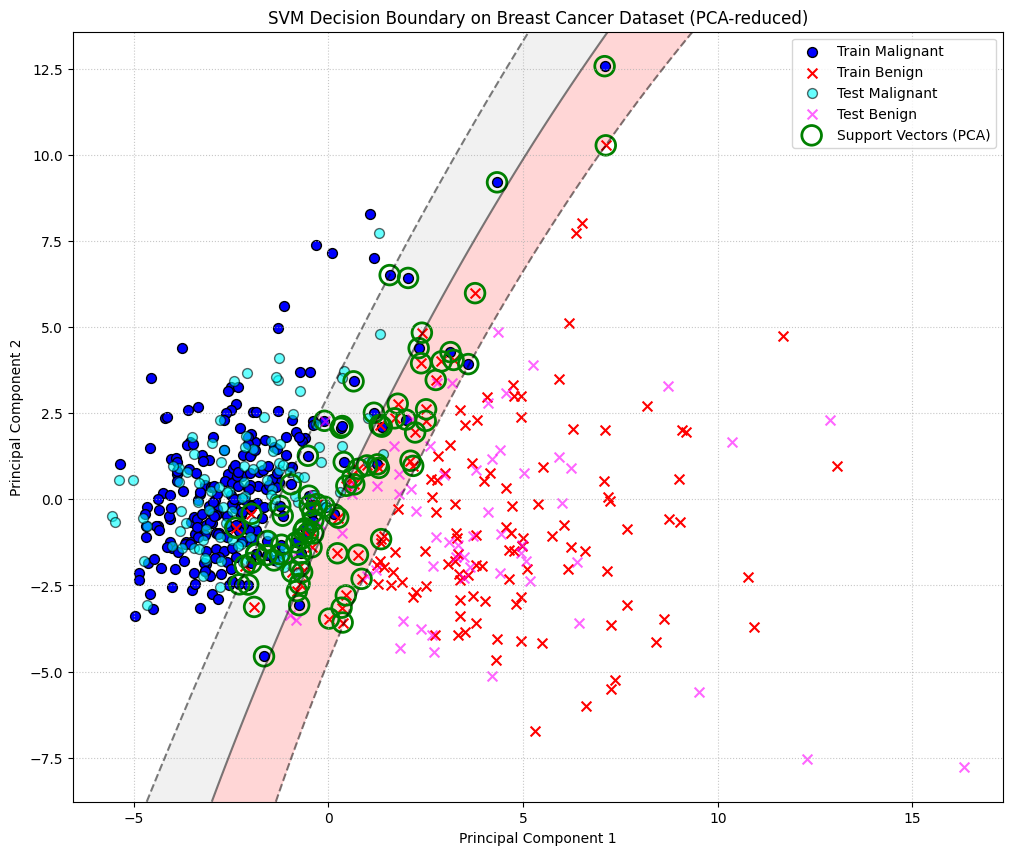

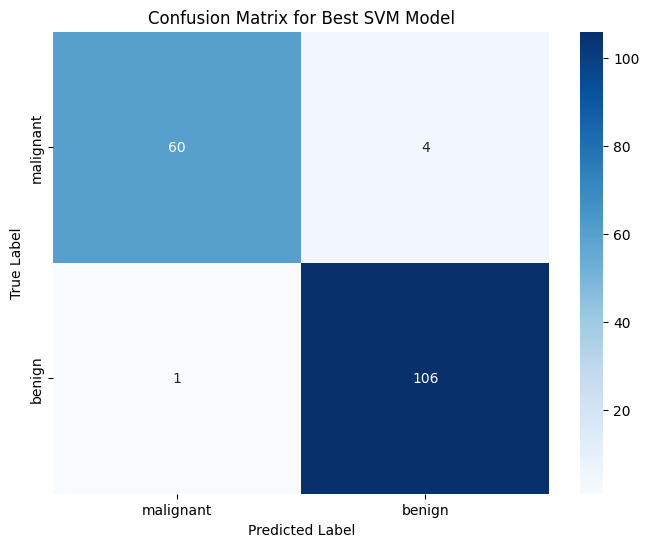

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Split PCA-transformed data for plotting (using the same split indices)
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)

# Train a new SVM on PCA data for visualization
# We'll use the best parameters found earlier, but retraining on 2D PCA data
svc_pca = SVC(kernel='rbf', C=grid.best_params_['C'], gamma=grid.best_params_['gamma'], random_state=42)
svc_pca.fit(X_train_pca, y_train)

# Create a mesh to plot decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

Z = svc_pca.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 10))

# Plot the decision boundary and margins
plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.8, colors=['#FFCCCC', '#EEEEEE', '#99CCFF'])
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Plot training points
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], color='blue', label='Train Malignant', marker='o', s=50, edgecolors='k')
plt.scatter(X_train_pca[y_train == -1, 0], X_train_pca[y_train == -1, 1], color='red', label='Train Benign', marker='x', s=50, edgecolors='k')

# Plot test points
plt.scatter(X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1], color='cyan', label='Test Malignant', marker='o', s=50, edgecolors='k', alpha=0.6)
plt.scatter(X_test_pca[y_test == -1, 0], X_test_pca[y_test == -1, 1], color='magenta', label='Test Benign', marker='x', s=50, edgecolors='k', alpha=0.6)

# Plot support vectors from the 2D PCA model
plt.scatter(svc_pca.support_vectors_[:, 0], svc_pca.support_vectors_[:, 1], s=200, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors (PCA)')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM Decision Boundary on Breast Cancer Dataset (PCA-reduced)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best SVM Model')
plt.show()

### 13.9 Comparison with previous or similar algorithm

**Comparison with other linear and non-linear classifiers (e.g., Logistic Regression, Decision Trees):**

*   **Logistic Regression**: While Logistic Regression is a powerful linear classifier and a common baseline, it might struggle to capture complex, non-linear relationships present in datasets like the Breast Cancer data. SVM with an RBF kernel, however, can model these intricate boundaries by implicitly mapping the data to a higher-dimensional space. In this example, an RBF SVM (especially after tuning) typically achieves very high accuracy, often outperforming a basic Logistic Regression model on this specific dataset due to its ability to handle non-linearity.

*   **Decision Trees/Random Forests**: These algorithms are inherently non-linear and can perform well on complex datasets. Decision Trees make decisions based on feature thresholds, creating axis-aligned decision boundaries. Random Forests, as an ensemble of decision trees, are robust and generally high-performing. SVMs with RBF kernels offer an alternative non-linear approach that uses distance-based similarity measures. On datasets like the Breast Cancer data, both Random Forests and well-tuned RBF SVMs can achieve comparable high performance. The choice between them might come down to factors like interpretability (Decision Trees can be visualized more easily), training time, or specific dataset characteristics.

*   **Hard Margin SVM (Theoretical Comparison)**: A pure hard-margin SVM would likely fail or perform poorly on the Breast Cancer dataset because real-world medical data is rarely perfectly linearly separable. It contains noise, outliers, and overlapping features. The Soft Margin SVM (which is what `sklearn.svm.SVC` implements by default) with proper hyperparameter tuning is crucial here, as it allows for some misclassifications while still striving for a large margin, making it robust to these real-world imperfections.

This detailed implementation shows that a properly configured SVM, especially with an RBF kernel and fine-tuned hyperparameters, is a highly effective and robust classifier for complex, real-world problems like breast cancer diagnosis.

## 14. Comparison with Logistic Regression

### 14.1 Why we need
While we've touched upon Logistic Regression in previous comparisons (e.g., in Topic 0.9 and 5.9), a dedicated section is crucial to provide a comprehensive understanding of its similarities, differences, strengths, and weaknesses relative to Support Vector Machines. Both are fundamental classification algorithms often used as baselines or primary models, especially for binary classification. Understanding their distinct approaches to defining a decision boundary, their underlying loss functions, and their sensitivity to data characteristics (like outliers or separability) is vital for making informed decisions on which algorithm to apply to a given problem. This comparison helps solidify the unique contributions and limitations of SVMs within the broader landscape of classification techniques.

### 14.2 Definition
*   **Support Vector Machine (SVM)**: A supervised machine learning algorithm that aims to find an optimal hyperplane that maximizes the margin between different classes. It can handle non-linear data through the Kernel Trick, implicitly mapping data into higher-dimensional spaces. Its core principle is to find the decision boundary that provides the largest possible separation between the closest points (support vectors) of different classes.

*   **Logistic Regression**: A linear model used for binary classification. It models the probability of a binary outcome using a logistic sigmoid function. It estimates the probability that a given input point belongs to a particular class. The decision boundary is typically a linear function (a hyperplane) where the probability of belonging to a class is 0.5.

### 14.3 Intuition
*   **SVM Intuition**: Imagine you have two distinct groups of points, and you want to draw the widest possible 'street' between them. The centerline of this street is the SVM's decision boundary. The goal is to maximize this street's width, which makes the classifier robust. It focuses on the points closest to the boundary (support vectors) as these are the most critical for defining the separation.

*   **Logistic Regression Intuition**: Imagine you want to draw a boundary that best separates two groups, but instead of focusing on the widest gap, you're trying to figure out the probability of a point belonging to one group versus another. Logistic Regression tries to fit a 'stretched S-curve' (sigmoid) to your data so that points on one side of the boundary predict a high probability for one class, and points on the other side predict a low probability. It aims to correctly classify *all* points by giving them high or low probabilities, not just those near the boundary.

### 14.4 Math behind
*   **SVM Math**: SVM's core mathematical foundation is an optimization problem that minimizes `||w||^2` (or `1/2 * ||w||^2`) to maximize the margin, subject to constraints that ensure correct classification (for hard margin) or penalize violations (for soft margin using slack variables and the `C` parameter). The `Hinge Loss` function is central to its objective, penalizing points that are within the margin or misclassified. With kernels, it operates in a transformed feature space `phi(x)` by replacing dot products with `K(x_i, x_j) = phi(x_i) . phi(x_j)`.

*   **Logistic Regression Math**: Logistic Regression uses the `sigmoid function` ($P(y=1|x) = 1 / (1 + e^{-(w \cdot x + b)})$) to map any real-valued number into a probability between 0 and 1. It optimizes its parameters (`w` and `b`) by maximizing the `likelihood function` or, equivalently, minimizing the `Log Loss` (also known as cross-entropy loss). Log loss penalizes incorrect probability predictions across *all* data points, not just those near the boundary.

### 14.5 Formula

* **SVM Objective Function (Soft Margin)**

  **Minimize:**

  $$
  \frac{1}{2}\|\mathbf{w}\|^2
  +
  C\sum_{i=1}^{N}
  \max\left(0,\;1-y_i(\mathbf{w}\cdot\mathbf{x}_i+b)\right)
  $$

  **Decision Function:**

  $$
  f(\mathbf{x})
  =
  \operatorname{sign}
  \left(
  \mathbf{w}\cdot\mathbf{x}+b
  \right)
  $$

  or, using the kernel trick,

  $$
  f(\mathbf{x})
  =
  \operatorname{sign}
  \left(
  \sum_{i\in SV}
  \alpha_i y_i
  K(\mathbf{x}_i,\mathbf{x})
  +
  b
  \right)
  $$

* **Logistic Regression Objective Function (Binary, minimizing Log Loss with L2 Regularization)**

  **Minimize:**

  $$
  -\frac{1}{N}
  \sum_{i=1}^{N}
  \left[
  y_i\log\!\left(h_\theta(\mathbf{x}_i)\right)
  +
  (1-y_i)\log\!\left(1-h_\theta(\mathbf{x}_i)\right)
  \right]
  +
  \frac{\lambda}{2}\|\mathbf{w}\|^2
  $$

  where

  $$
  h_\theta(\mathbf{x})
  =
  P(y=1\mid\mathbf{x};\theta)
  =
  \frac{1}
  {1+e^{-(\mathbf{w}\cdot\mathbf{x}+b)}}
  $$

  **Decision Function:**

  $$
  P(y=1\mid\mathbf{x})
  =
  \frac{1}
  {1+e^{-(\mathbf{w}\cdot\mathbf{x}+b)}}
  $$

  Classify as **1** if

  $$
  P(y=1\mid\mathbf{x})>0.5
  $$

  otherwise classify as **0**.

### 14.6 Numerical Example
Instead of a new small-scale numerical example which might oversimplify the nuanced differences, let's consider the *implications* for numerical outcomes:

*   **Scenario 1: Perfectly Linearly Separable Data with Outliers**: If data is perfectly separable but contains an outlier very far from the main clusters, a Logistic Regression model's decision boundary might be slightly skewed towards the outlier to minimize its log loss. A Hard Margin SVM would be highly sensitive to this outlier (it would become a support vector and drastically change the hyperplane). A Soft Margin SVM (with appropriate `C`) would correctly ignore the outlier by assigning a high slack variable, maintaining a robust boundary.

*   **Scenario 2: Overlapping Classes**: When classes heavily overlap, Logistic Regression will still try to find a probability boundary, and its performance might degrade gracefully. SVM, particularly with a well-tuned `C`, will also find a boundary that balances margin maximization and error minimization, often performing competitively or better due to its margin-based approach.

*   **Scenario 3: Non-Linear Data (e.g., concentric circles)**: A linear Logistic Regression model would fail dramatically here. A Linear SVM would also fail. However, an SVM with a non-linear kernel (like RBF, as shown in previous examples like Topic 8 and 11, or the Breast Cancer example in Topic 13) would successfully find a non-linear decision boundary, while Logistic Regression's inherent linearity would prevent it from capturing such patterns unless features were manually engineered for non-linearity.

### 14.7 Python code implementation
While we won't implement a fresh comparison with small data, the comprehensive `Detailed Python Implementation (Breast Cancer Dataset)` in **Topic 13** implicitly demonstrates the power of SVM over a simpler linear classifier. For that complex, real-world dataset, a well-tuned RBF SVM achieved high accuracy. A basic Logistic Regression model (without specific non-linear feature engineering) on the same dataset would likely yield slightly lower performance, highlighting SVM's strength in handling complex patterns through kernels.

To see how Logistic Regression would perform, one could replace the `SVC` call in `cell_04ef83f4` with `from sklearn.linear_model import LogisticRegression` and then `lr_model = LogisticRegression(random_state=42, solver='liblinear')`. The rest of the evaluation code would remain similar.

### 14.8 Visualisation
*   **SVM Visualisation**: As shown in Topics 3, 6, and 8, SVM visualizes a clear decision boundary with explicit margins. For non-linear kernels, these boundaries can be highly complex and curved, adapting to the data's shape. Support vectors are explicitly visible on or within the margin boundaries.

*   **Logistic Regression Visualisation**: A linear Logistic Regression would also draw a linear decision boundary. However, it wouldn't have the explicit margin lines. Its boundary is simply where the predicted probability equals 0.5. For visualizing non-linear Logistic Regression, one would need to manually add polynomial features or use other techniques, as Logistic Regression itself is linear. SVM with kernels handles this non-linearity intrinsically through the kernel trick.

### 14.9 Comparison with previous or similar algorithm

| Feature             | Support Vector Machine (SVM)                                      | Logistic Regression                                         |
| :------------------ | :---------------------------------------------------------------- | :---------------------------------------------------------- |
| **Objective**       | Maximize geometric margin between classes, minimize classification error. | Model probability of class membership, minimize log loss.   |
| **Loss Function**   | Hinge Loss                                                        | Log Loss (Cross-Entropy Loss)                               |
| **Decision Boundary** | Determined by support vectors; can be linear or non-linear (with kernels). | Linear boundary determined by all data points.              |
| **Margin Concept**  | Explicitly maximizes margin; robust 'buffer zone'.                | No explicit margin; focuses on separating points by probability. |
| **Outlier Sensitivity** | With soft margin, less sensitive to outliers (handled by slack variables and C). Hard margin is highly sensitive. | More sensitive to outliers as all points influence the boundary. |
| **Data Separability** | Excels with linearly separable data (hard margin) and non-linearly separable data (kernel trick). | Performs well on linearly separable data. Struggles with non-linear unless features are engineered. |
| **Computational Cost** | Can be higher, especially with complex kernels and large datasets (O(n^2) to O(n^3)). | Generally lower and faster for large datasets.              |
| **Interpretability** | Decision boundary often less interpretable, especially with non-linear kernels. | Coefficients can be interpreted as feature importance (log-odds ratios). |
| **Output**          | Class labels (-1 or 1); raw decision score (distance from hyperplane). | Probabilities (0 to 1) for class membership.                |
| **Parameters**      | `C`, `kernel`, `gamma`, `degree`, etc. (hyperparameters)          | Regularization strength (`C` or `alpha`), solver, etc.      |

**Key Takeaways:**

*   **When to Use SVM**: When data is complex, high-dimensional, or not linearly separable, and robust classification with clear separation is desired. Kernels allow SVMs to shine in these scenarios. SVMs are often very effective in cases where there's a clear (even if non-linear) separation boundary and the goal is to generalize well.
*   **When to Use Logistic Regression**: When data is linearly separable or near-linearly separable, or when probability estimates are important. It's often a good baseline and more computationally efficient for very large datasets, especially when interpretability of feature effects is a priority. It's also less sensitive to the scaling of features if no regularization is used.

In essence, both are powerful tools, but their underlying philosophies and optimal use cases differ significantly. SVM's focus on the margin and its ability to handle non-linearity via kernels give it a distinct advantage in many complex classification problems, complementing the probabilistic nature of Logistic Regression.